# CE49X: Introduction to Computational Thinking and Data Science for Civil Engineers
## Week 5: Statistical Analysis — Are Extreme Temperatures Getting More Extreme?

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

> *"2023 and 2024 were the hottest years ever recorded. Is the world just getting warmer on average — or are we also seeing more extreme temperatures?"*

Today we investigate **270 years of real temperature data** from cities across the globe. Along the way, we will build up the statistical toolkit — descriptive statistics, distributions, z-scores, and hypothesis testing — needed to answer this question rigorously.

**Our hypotheses:**
- **H₁**: Mean temperatures in major world cities have significantly increased (1980–2013 vs 1900–1950)
- **H₂**: Extreme temperature months (beyond ±2σ of historical baseline) have become more frequent

### Topics Covered
1. Data Cleaning & Exploration
2. Descriptive Statistics (mean, median, std, IQR, skewness, kurtosis)
3. Visualizing Distributions (histograms, boxplots, normal distribution, 68-95-99.7 rule)
4. Z-Scores & Defining "Extreme"
5. Hypothesis Testing (t-test, proportion test)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 120)
plt.rcParams['figure.dpi'] = 100

**What did we just import?**

- `numpy` — fast numerical computation (arrays, math)
- `pandas` — data tables (like Excel, but programmable)
- `matplotlib` — plotting and visualization
- `scipy.stats` — statistical functions (distributions, tests)

These four libraries are the workhorses of data science in Python. You'll use them in almost every analysis.

### Loading the Data

We use the **Berkeley Earth Surface Temperature** dataset — monthly average temperatures for ~100 major cities worldwide, spanning 1743 to 2013.

*Source: Berkeley Earth / Kaggle (Creative Commons license)*

In [2]:
df_raw = pd.read_csv('data/GlobalLandTemperaturesByMajorCity.csv')

print(f'Dataset: {df_raw.shape[0]:,} rows \u00d7 {df_raw.shape[1]} columns')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head()

Dataset: 239,177 rows × 7 columns
Columns: ['dt', 'AverageTemperature', 'AverageTemperatureUncertainty', 'City', 'Country', 'Latitude', 'Longitude']


,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1849-01-01,26.704,1.435,Abidjan,Côte D'Ivoire,5.63N,3.23W
1,1849-02-01,27.434,1.362,Abidjan,Côte D'Ivoire,5.63N,3.23W
2,1849-03-01,28.101,1.612,Abidjan,Côte D'Ivoire,5.63N,3.23W
3,1849-04-01,26.140,1.387,Abidjan,Côte D'Ivoire,5.63N,3.23W
4,1849-05-01,25.427,1.200,Abidjan,Côte D'Ivoire,5.63N,3.23W


Take a moment to look at the output above. We have nearly **240,000 rows** — each row is one city in one month. For example, "Abidjan, January 1849, average temperature 26.7°C."

The columns are:
- `dt` — the date (year-month-day, always the 1st of the month)
- `AverageTemperature` — the monthly average in °C
- `AverageTemperatureUncertainty` — how confident the measurement is (higher = less certain)
- `City`, `Country` — where
- `Latitude`, `Longitude` — geographic coordinates

**Question:** Why might `AverageTemperatureUncertainty` be important? *Think about measurements from 1750 vs. 2010 — which would you trust more?*

Now let's clean this up and focus on the cities we care about.

---
## Part 1: Meet the Data — Cleaning & Exploration

> **Key Insight: Real Data Is Messy**  
> Before any statistical analysis, we must understand our data: What's in it? What's missing? What needs fixing?  
> Skipping this step is the #1 source of wrong conclusions in data science.

In [3]:
# Parse dates and extract useful time columns
df_raw['dt'] = pd.to_datetime(df_raw['dt'])
df_raw['year'] = df_raw['dt'].dt.year
df_raw['month'] = df_raw['dt'].dt.month

print(f'Date range: {df_raw["dt"].min().date()} to {df_raw["dt"].max().date()}')
print(f'Number of cities: {df_raw["City"].nunique()}')
print(f'Missing temperatures: {df_raw["AverageTemperature"].isna().sum():,} / {len(df_raw):,} '
      f'({df_raw["AverageTemperature"].isna().mean():.1%})')

Date range: 1743-11-01 to 2013-09-01
Number of cities: 100
Missing temperatures: 11,002 / 239,177 (4.6%)


**What did we just do?**

We told pandas to treat the `dt` column as a proper date (not just text), and we extracted the **year** and **month** into separate columns.

**Why does this matter?** Later, we'll need to:
- Compare "all Augusts from 1900 to 1950" with "all Augusts from 1980 to 2013" → requires the `month` column
- Group data by decade → requires the `year` column
- Filter to reliable time periods → requires the `year` column

This kind of **feature engineering** — creating new columns from existing ones — is a crucial data science skill.

In [4]:
# Select 8 target cities — one per continent + Istanbul for local relevance
target_cities = ['Istanbul', 'London', 'New York', 'Tokyo',
                 'Sydney', 'Cairo', 'S\u00e3o Paulo', 'Bombay']

# Mumbai was called Bombay in historical records (renamed in 1995)
display_names = {'Bombay': 'Mumbai', 'S\u00e3o Paulo': 'S\u00e3o Paulo',
                 'New York': 'New York', 'Istanbul': 'Istanbul',
                 'London': 'London', 'Tokyo': 'Tokyo',
                 'Sydney': 'Sydney', 'Cairo': 'Cairo'}

df = df_raw[df_raw['City'].isin(target_cities)].copy()
df['CityLabel'] = df['City'].map(display_names)

print(f'Filtered to {len(df):,} rows across {df["City"].nunique()} cities')

Filtered to 21,069 rows across 8 cities


**Why these 8 cities?**

We chose one city per continent, plus Istanbul for local relevance:

| City | Continent | Climate Type |
|---|---|---|
| Istanbul | Europe/Asia | Mediterranean/Continental |
| London | Europe | Maritime |
| New York | North America | Continental |
| Tokyo | Asia | Humid subtropical |
| Sydney | Oceania | Maritime |
| Cairo | Africa | Desert |
| São Paulo | South America | Subtropical |
| Mumbai | Asia | Tropical monsoon |

This gives us a diverse sample of climate types. If we find the **same pattern** across all of them, it's much stronger evidence than finding it in just one city.

*(Note: Mumbai appears as "Bombay" in the dataset — the city was officially renamed in 1995.)*

### Data Quality: What's Missing?

Real-world datasets always have gaps. Early temperature records were sparse and inconsistent. Let's see where the holes are.

In [5]:
# Data coverage summary per city
print(f'{"City":<15} {"First Year":>10} {"Last Year":>10} {"Records":>8} {"Missing":>8} {"% Missing":>10}')
print('-' * 65)

for city in target_cities:
    subset = df[df['City'] == city]
    n_missing = subset['AverageTemperature'].isna().sum()
    label = display_names[city]
    print(f'{label:<15} {subset["year"].min():>10} {subset["year"].max():>10} '
          f'{len(subset):>8,} {n_missing:>8} {n_missing/len(subset):>10.1%}')

City            First Year  Last Year  Records  Missing  % Missing
-----------------------------------------------------------------
Istanbul              1743       2013    3,239       73       2.3%
London                1743       2013    3,239       73       2.3%
New York              1743       2013    3,239      120       3.7%
Tokyo                 1845       2013    2,025        5       0.2%
Sydney                1841       2013    2,073        2       0.1%
Cairo                 1808       2013    2,460       18       0.7%
São Paulo             1832       2013    2,181       85       3.9%
Mumbai                1796       2013    2,613      105       4.0%


**What do you notice?**

Look at the "First Year" column. Istanbul, London, and New York have records stretching back to the **1740s** — almost 300 years! But Tokyo only starts in 1845, and Cairo in 1808. This reflects which cities had organized weather stations earliest.

**Why do some cities have more missing data?**
- Wars, political upheaval, or equipment failures can create gaps
- Early instruments were less reliable
- Some stations were established later than others

> **Key Insight: Understand Your Data Before You Analyze It**  
> If we naively computed averages including the 1743–1849 period, we'd only be averaging Istanbul, London, and New York — biasing our "global" analysis. This is why we need to filter to a common time period.

**Question:** If you were writing a research paper, would you start your analysis from 1743 or from a later date? What are the trade-offs?

In [6]:
# Filter to 1850-2013 (reliable coverage) and drop missing values
df = df[(df['year'] >= 1850) & (df['year'] <= 2013)].copy()
df = df.dropna(subset=['AverageTemperature'])

print(f'After filtering to 1850-2013 and dropping NaN: {len(df):,} rows')
print()
print('Records per city:')
print(df.groupby('CityLabel').size().sort_values(ascending=False).to_string())

After filtering to 1850-2013 and dropping NaN: 15,663 rows

Records per city:
CityLabel
New York     1965
Cairo        1964
Istanbul     1964
London       1964
Sydney       1963
Tokyo        1960
São Paulo    1952
Mumbai       1931


Good — after filtering to 1850–2013 and dropping missing values, we still have a **large, clean dataset** to work with. Each city has roughly 1,900 monthly records — that's more than enough for robust statistical analysis.

Notice that we lost some rows by dropping NaN values. This is a judgment call — we could have tried to fill in missing values ("imputation"), but for this analysis, simply dropping them is the safer and more honest approach.

**[QUICK]** Look at the tables above:
1. How many total observations do we have across all cities?
2. Which city has data going back the farthest?
3. Which city has the most missing data — and why might that be?

In [7]:
# Quick exploration of the clean dataset
print('Overall dataset summary:')
print(df['AverageTemperature'].describe().round(2))
print()
print(f'Year range: {df["year"].min()} - {df["year"].max()}')
print(f'Total observations: {len(df):,}')

Overall dataset summary:
count    15663.00
mean        16.28
std          8.08
min         -9.16
25%         10.98
50%         17.29
75%         22.35
max         30.77
Name: AverageTemperature, dtype: float64

Year range: 1850 - 2013
Total observations: 15,663


---
## Part 2: Descriptive Statistics — What's "Normal" for Each City?

> **Key Insight: To Detect the Abnormal, First Define Normal**  
> We can't say a temperature is "extreme" without knowing what typical temperatures look like.  
> Descriptive statistics give us the vocabulary to describe "typical."

In [8]:
# Overall descriptive statistics for each city
desc = df.groupby('CityLabel')['AverageTemperature'].agg(
    ['mean', 'median', 'std', 'min', 'max', 'count']
).round(2)

desc.columns = ['Mean (°C)', 'Median (°C)', 'Std Dev', 'Min (°C)', 'Max (°C)', 'Records']
desc = desc.sort_values('Mean (°C)', ascending=False)

print('Descriptive Statistics: Monthly Average Temperature by City')
print()
desc

Descriptive Statistics: Monthly Average Temperature by City



,Mean (°C),Median (°C),Std Dev,Min (°C),Max (°C),Records
CityLabel,,,,,,
Mumbai,26.75,26.98,1.59,21.86,30.68,1931
Cairo,21.37,22.07,5.59,10.33,30.77,1964
São Paulo,19.75,19.81,2.50,13.54,25.22,1952
Sydney,17.03,17.12,2.19,12.00,22.04,1963
Istanbul,13.65,13.65,6.60,0.11,26.83,1964
Tokyo,12.57,13.16,8.24,-1.58,27.30,1960
New York,9.77,9.90,9.22,-9.16,25.31,1965
London,9.59,9.04,5.05,-2.46,20.74,1964


**How to read this table — take a moment.**

Find the city with the **highest** mean temperature and the one with the **lowest**. The difference between them reflects the geographic diversity in our dataset — from equatorial Mumbai to temperate London.

Now focus on the **Std Dev** column. This is the most revealing column:
- **Low std dev** (≈2°C) → the city's temperature barely changes month to month → tropical climate
- **High std dev** (≈8°C) → dramatic seasonal swings → continental climate

**Question:** Which city has the largest standard deviation? What does that tell you about living and building infrastructure there?

**Question:** Why is the median sometimes different from the mean? What would cause them to diverge?

Let's now formally define these quantities.

### Formal Definitions

These are the formulas behind the numbers above.

**Sample Mean (Arithmetic Average):**

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$$

**Sample Variance:**

$$s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2$$

We use $n-1$ (Bessel's correction) because we're estimating the population variance from a sample.

**Sample Standard Deviation:**

$$s = \sqrt{s^2}$$

> The standard deviation tells us the **typical distance** of a data point from the mean. A small $s$ means data is tightly clustered; a large $s$ means widely spread.

In [9]:
# Deep dive: Istanbul
ist = df[df['CityLabel'] == 'Istanbul']['AverageTemperature']

print('=== Istanbul Temperature Profile ===')
print(f'Mean:     {ist.mean():.2f}\u00b0C  \u2014 the "center" of the distribution')
print(f'Median:   {ist.median():.2f}\u00b0C  \u2014 half the months are above, half below')
print(f'Std Dev:  {ist.std():.2f}\u00b0C  \u2014 typical distance from the mean')
print(f'Min:      {ist.min():.2f}\u00b0C  \u2014 coldest month on record')
print(f'Max:      {ist.max():.2f}\u00b0C  \u2014 hottest month on record')
print(f'Range:    {ist.max() - ist.min():.2f}\u00b0C  \u2014 total spread')
print()
print(f'Interpretation: Istanbul\'s mean is ~14\u00b0C, but with a std of ~7\u00b0C.')
print(f'This huge spread reflects real seasons \u2014 cold winters and hot summers.')

=== Istanbul Temperature Profile ===
Mean:     13.65°C  — the "center" of the distribution
Median:   13.65°C  — half the months are above, half below
Std Dev:  6.60°C  — typical distance from the mean
Min:      0.11°C  — coldest month on record
Max:      26.83°C  — hottest month on record
Range:    26.73°C  — total spread

Interpretation: Istanbul's mean is ~14°C, but with a std of ~7°C.
This huge spread reflects real seasons — cold winters and hot summers.


**Let's make sure we understand what these numbers mean physically.**

Istanbul's mean is about 14°C. But that doesn't mean Istanbul "feels like" 14°C — almost no month is actually close to 14°C! The mean is an average across freezing winters and sweltering summers. It's a useful summary, but it hides the full picture.

The standard deviation of ~7°C tells us that a "typical" month deviates from the mean by about 7 degrees in either direction. That's a huge swing.

**Analogy:** Imagine someone tells you a river's average depth is 1 meter. Would you walk across it? Not if some parts are 3 meters deep! The standard deviation tells you about those dangerous deeper parts.

### Comparing Spread: Tropical vs. Continental

The standard deviation reveals something fundamental about a city's climate character.

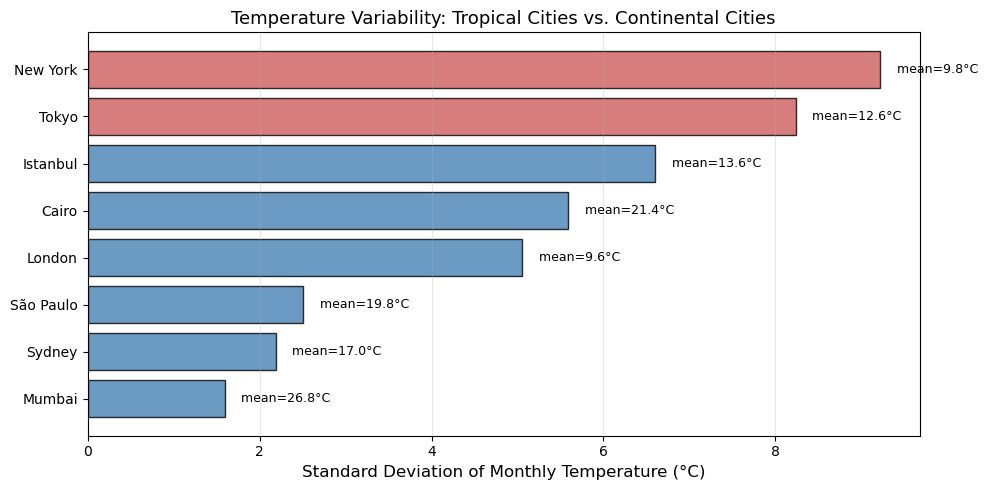

Low std → tropical/equatorial (small seasonal swings)
High std → continental/temperate (big seasonal swings)


In [10]:
# Compare std across cities — reveals climate type
fig, ax = plt.subplots(figsize=(10, 5))

city_stats = df.groupby('CityLabel')['AverageTemperature'].agg(['mean', 'std']).sort_values('std')

colors = ['indianred' if std > 7 else 'steelblue' for std in city_stats['std']]
bars = ax.barh(city_stats.index, city_stats['std'], color=colors, edgecolor='black', alpha=0.8)
ax.set_xlabel('Standard Deviation of Monthly Temperature (\u00b0C)', fontsize=12)
ax.set_title('Temperature Variability: Tropical Cities vs. Continental Cities', fontsize=13)
ax.grid(True, alpha=0.3, axis='x')

# Add mean temperature annotation
for i, (idx, row) in enumerate(city_stats.iterrows()):
    ax.text(row['std'] + 0.1, i, f'  mean={row["mean"]:.1f}\u00b0C', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('Low std \u2192 tropical/equatorial (small seasonal swings)')
print('High std \u2192 continental/temperate (big seasonal swings)')

**What does this chart reveal?**

The cities naturally split into two groups:
- **Tropical/equatorial cities** (Mumbai, Cairo, São Paulo) — low variability, consistently warm year-round
- **Continental/temperate cities** (Istanbul, New York, Tokyo) — high variability, dramatic seasons

London is interesting — it's at a high latitude but has lower variability than you'd expect. Why? The **Gulf Stream** moderates its climate, keeping winters milder and summers cooler than continental cities at the same latitude.

**Question:** If you were designing a bridge in Mumbai vs. Istanbul, how would the different temperature variability affect your thermal expansion calculations?

### IQR and the Five-Number Summary

The **five-number summary** provides a robust overview of data distribution:
- Minimum
- First Quartile ($Q_1$, 25th percentile)
- Median ($Q_2$, 50th percentile)
- Third Quartile ($Q_3$, 75th percentile)
- Maximum

**Interquartile Range (IQR):**

$$\text{IQR} = Q_3 - Q_1$$

The IQR captures the middle 50% of the data and is **robust to outliers** — unlike the range or standard deviation.

In [11]:
# Five-number summary for each city
print(f'{"City":<15} {"Min":>8} {"Q1":>8} {"Median":>8} {"Q3":>8} {"Max":>8} {"IQR":>8}')
print('-' * 65)

for city in sorted(df['CityLabel'].unique()):
    temps = df[df['CityLabel'] == city]['AverageTemperature']
    q1, q2, q3 = np.percentile(temps, [25, 50, 75])
    print(f'{city:<15} {temps.min():>8.1f} {q1:>8.1f} {q2:>8.1f} {q3:>8.1f} {temps.max():>8.1f} {q3-q1:>8.1f}')

City                 Min       Q1   Median       Q3      Max      IQR
-----------------------------------------------------------------
Cairo               10.3     15.9     22.1     26.8     30.8     10.8
Istanbul             0.1      7.7     13.6     19.9     26.8     12.2
London              -2.5      5.3      9.0     14.4     20.7      9.1
Mumbai              21.9     25.7     27.0     27.9     30.7      2.2
New York            -9.2      1.2      9.9     18.7     25.3     17.5
Sydney              12.0     15.2     17.1     18.9     22.0      3.8
São Paulo           13.5     17.7     19.8     21.9     25.2      4.3
Tokyo               -1.6      4.5     13.2     20.2     27.3     15.7


Take a moment to read this table row by row. For each city, the five numbers tell a complete story:

- **Mumbai**: Min and Max are relatively close. The IQR is tiny (~3°C). This city's temperature barely fluctuates.
- **Istanbul and New York**: Huge ranges and IQRs. These cities experience dramatic seasonal swings.
- **Cairo**: Warm overall, but notice the IQR is moderate — it's somewhere in between.

**Question:** Which city would be the most challenging from a thermal expansion perspective for outdoor infrastructure? Why?

The five-number summary is powerful, but it's hard to compare 8 cities by reading rows of numbers. Let's **visualize** them with boxplots.

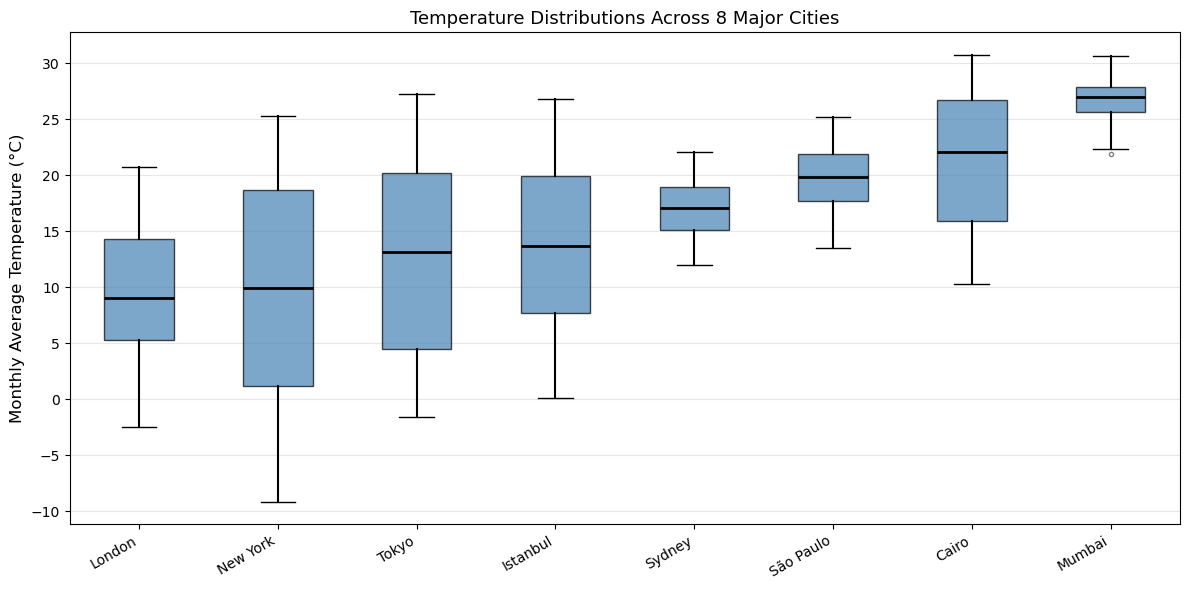

In [12]:
# Boxplots by city — the five-number summary visualized
fig, ax = plt.subplots(figsize=(12, 6))

city_order = df.groupby('CityLabel')['AverageTemperature'].median().sort_values().index
data_for_box = [df[df['CityLabel'] == city]['AverageTemperature'].values for city in city_order]

bp = ax.boxplot(data_for_box, tick_labels=city_order, patch_artist=True, vert=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(linewidth=1.5),
                flierprops=dict(marker='o', markersize=3, alpha=0.5))

ax.set_ylabel('Monthly Average Temperature (\u00b0C)', fontsize=12)
ax.set_title('Temperature Distributions Across 8 Major Cities', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Reading boxplots — a visual guide:**

Each box shows the **middle 50%** of the data (from Q1 to Q3 — the IQR). The horizontal line inside the box is the **median**. The whiskers extend to the most extreme non-outlier data points. Dots beyond the whiskers are **outliers** — unusually extreme months.

**What do the boxplots reveal?**
- Mumbai's box is tiny → remarkably stable temperatures
- Istanbul and New York have the tallest boxes → biggest seasonal swings
- Some cities show outlier dots — these are months with unusual temperatures

**Question for discussion:** Why does London's box seem narrower than New York's, even though they're at similar latitudes? *(Hint: think about the Gulf Stream and maritime vs. continental climate.)*

**Question:** Do you notice any outlier dots? What could cause an unusually extreme month?

### Shape Measures: Skewness and Kurtosis

**Skewness** measures the asymmetry of the distribution:

$$\gamma_1 = \frac{1}{n}\sum_{i=1}^{n}\left(\frac{x_i - \bar{x}}{s}\right)^3$$

- $\gamma_1 = 0$: Symmetric
- $\gamma_1 > 0$: Right-skewed (long right tail)
- $\gamma_1 < 0$: Left-skewed (long left tail)

**Excess Kurtosis** measures the "tailedness" relative to a normal distribution:

$$\gamma_2 = \frac{1}{n}\sum_{i=1}^{n}\left(\frac{x_i - \bar{x}}{s}\right)^4 - 3$$

- $\gamma_2 = 0$: Normal-like tails
- $\gamma_2 > 0$: Heavier tails (more extreme values than normal)
- $\gamma_2 < 0$: Lighter tails (fewer extreme values)

In [13]:
# Skewness and kurtosis for each city
print('Shape Measures by City')
print()
print(f'{"City":<15} {"Skewness":>10} {"Ex. Kurtosis":>13}  Interpretation')
print('-' * 65)

for city in sorted(df['CityLabel'].unique()):
    temps = df[df['CityLabel'] == city]['AverageTemperature']
    skew = stats.skew(temps)
    kurt = stats.kurtosis(temps)
    skew_interp = 'right-skewed' if skew > 0.3 else 'left-skewed' if skew < -0.3 else '~symmetric'
    kurt_interp = 'heavy tails' if kurt > 0.5 else 'light tails' if kurt < -0.5 else '~normal tails'
    print(f'{city:<15} {skew:>10.3f} {kurt:>13.3f}  {skew_interp}, {kurt_interp}')

Shape Measures by City

City              Skewness  Ex. Kurtosis  Interpretation
-----------------------------------------------------------------
Cairo               -0.216        -1.381  ~symmetric, light tails
Istanbul            -0.018        -1.303  ~symmetric, light tails
London               0.069        -1.172  ~symmetric, light tails
Mumbai              -0.420        -0.438  left-skewed, ~normal tails
New York            -0.087        -1.345  ~symmetric, light tails
Sydney              -0.028        -1.098  ~symmetric, light tails
São Paulo           -0.142        -1.039  ~symmetric, light tails
Tokyo                0.040        -1.354  ~symmetric, light tails


**How to read this table:**

- Cities with skewness near **0** have roughly symmetric temperature distributions — cold extremes and hot extremes are equally likely
- **Negative skewness** means the left tail is longer — there are some unusually cold months pulling the distribution leftward
- **Excess kurtosis near -1** (light tails) is common for temperature data — unlike stock prices, temperatures don't have wild outliers very often

**Question:** Why might a city's temperature distribution be skewed? Think about what could make extremely cold months more common than extremely hot months (or vice versa).

Let's visualize this to make it concrete — seeing the shape is much more intuitive than reading numbers.

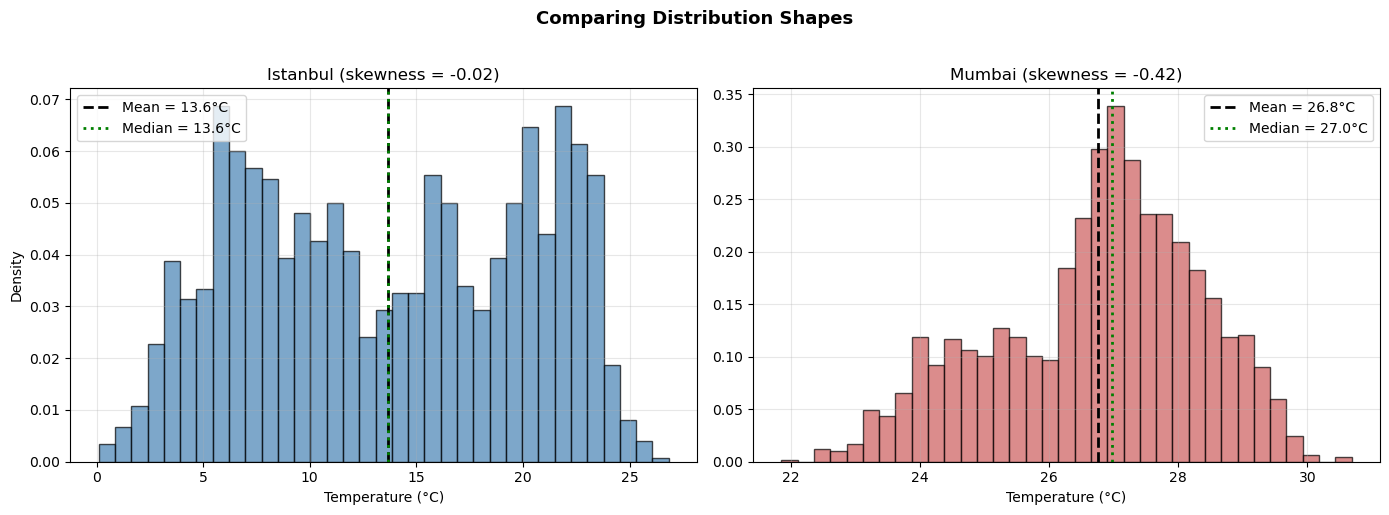

In [14]:
# Visualize skewness: compare a ~symmetric city with a skewed one
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, city, color in zip(axes, ['Istanbul', 'Mumbai'], ['steelblue', 'indianred']):
    temps = df[df['CityLabel'] == city]['AverageTemperature']
    ax.hist(temps, bins=35, color=color, edgecolor='black', alpha=0.7, density=True)
    ax.axvline(temps.mean(), color='black', linestyle='--', linewidth=2,
               label=f'Mean = {temps.mean():.1f}\u00b0C')
    ax.axvline(temps.median(), color='green', linestyle=':', linewidth=2,
               label=f'Median = {temps.median():.1f}\u00b0C')
    skew = stats.skew(temps)
    ax.set_title(f'{city} (skewness = {skew:.2f})', fontsize=12)
    ax.set_xlabel('Temperature (\u00b0C)')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Density')
plt.suptitle('Comparing Distribution Shapes', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**[TOGETHER]** Let's interpret Istanbul's statistics as a class:
1. Look at the mean and median — are they close? What does that tell us about symmetry?
2. The standard deviation is ~7°C — what does that mean physically?
3. What does the skewness value tell us about Istanbul's temperature distribution?
4. If you were designing a building's HVAC system, which statistics would you use?

In [15]:
# [TOGETHER] Istanbul: compare two eras
ist_data = df[df['CityLabel'] == 'Istanbul'].copy()

era1 = ist_data[(ist_data['year'] >= 1900) & (ist_data['year'] <= 1950)]['AverageTemperature']
era2 = ist_data[(ist_data['year'] >= 1980) & (ist_data['year'] <= 2013)]['AverageTemperature']

print('=== Istanbul: Two Eras Compared ===')
print()
print(f'{"Statistic":<20} {"1900-1950":>12} {"1980-2013":>12} {"Change":>10}')
print('-' * 58)
for name, func in [('Mean', np.mean), ('Median', np.median),
                    ('Std Dev', lambda x: np.std(x, ddof=1)),
                    ('Skewness', stats.skew), ('Kurtosis', stats.kurtosis)]:
    v1, v2 = func(era1), func(era2)
    print(f'{name:<20} {v1:>12.3f} {v2:>12.3f} {v2-v1:>+10.3f}')

print(f'\nThe mean has shifted by {np.mean(era2) - np.mean(era1):.2f}\u00b0C \u2014 is this significant? We will test this later!')

=== Istanbul: Two Eras Compared ===

Statistic               1900-1950    1980-2013     Change
----------------------------------------------------------
Mean                       13.599       14.121     +0.522
Median                     13.489       13.991     +0.502
Std Dev                     6.544        6.737     +0.193
Skewness                   -0.067        0.064     +0.130
Kurtosis                   -1.284       -1.347     -0.063

The mean has shifted by 0.52°C — is this significant? We will test this later!


> **Key Insight: Descriptive Statistics Tell You What Happened, Not Whether It Matters**  
> We've seen that Istanbul's mean temperature shifted upward. But is that shift big enough to be meaningful,
> or could it be random variation? We need formal statistical tests to answer that.

---
## Part 3: Visualizing Distributions — The Shape of Temperature

> **Key Insight: Numbers Summarize, But Plots Reveal the Full Story**  
> A mean and standard deviation compress thousands of data points into two numbers.  
> A histogram shows you what those numbers can't: the actual shape of the data.

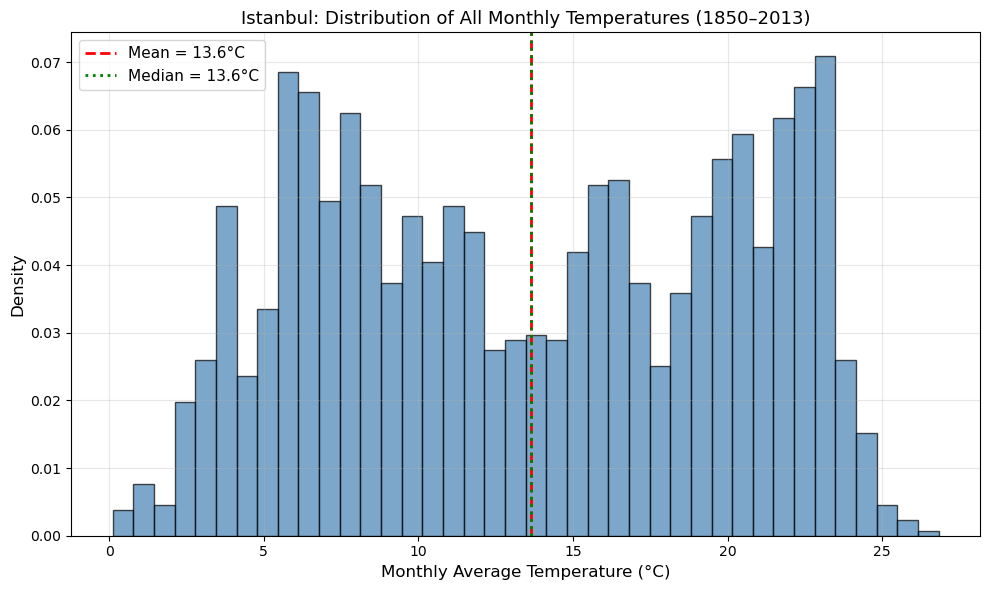

Notice the shape — it is NOT a simple bell curve!
The distribution is bimodal (two peaks): one for winter, one for summer.


In [16]:
# Histogram of all monthly temperatures for Istanbul
ist_all = df[df['CityLabel'] == 'Istanbul']['AverageTemperature']

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(ist_all, bins=40, color='steelblue', edgecolor='black', alpha=0.7, density=True)
ax.axvline(ist_all.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean = {ist_all.mean():.1f}\u00b0C')
ax.axvline(ist_all.median(), color='green', linestyle=':', linewidth=2,
           label=f'Median = {ist_all.median():.1f}\u00b0C')
ax.set_xlabel('Monthly Average Temperature (\u00b0C)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Istanbul: Distribution of All Monthly Temperatures (1850\u20132013)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Notice the shape \u2014 it is NOT a simple bell curve!')
print('The distribution is bimodal (two peaks): one for winter, one for summer.')

**Why is it bimodal (two humps)?**

Think about it: Istanbul has cold winters (~5°C average in January) and hot summers (~23°C average in August). When we plot ALL months together, we're mixing two very different populations — winter months and summer months. The result is two peaks, not one.

This is an important lesson: **the shape of a distribution depends on what data you include.** A single population often looks bell-shaped, but mixing populations creates multimodality.

**Question:** Would you expect Mumbai's histogram to also be bimodal? Why or why not?

*(Answer: No — Mumbai has very small seasonal variation, so all months cluster together in one peak.)*

Now let's compare two different time periods. If global warming is real, we should see the distribution **shift to the right** in the recent era.

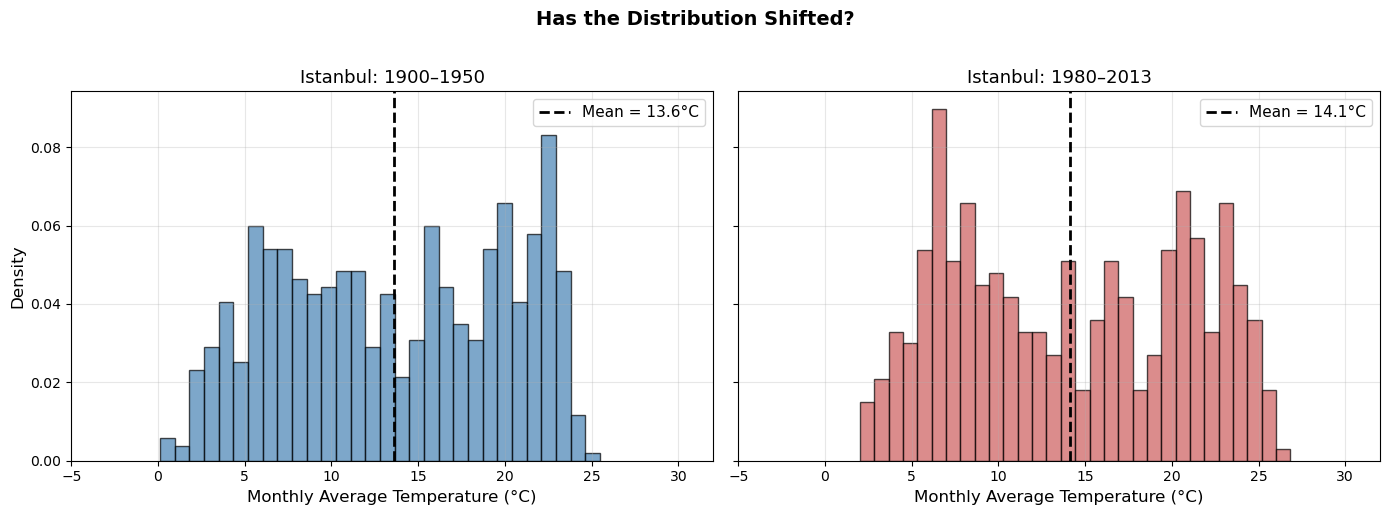

In [17]:
# Side-by-side: 1900-1950 vs 1980-2013 \u2014 can we SEE the warming?
ist_data = df[df['CityLabel'] == 'Istanbul'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (start, end), label, color in zip(
    axes,
    [(1900, 1950), (1980, 2013)],
    ['1900\u20131950', '1980\u20132013'],
    ['steelblue', 'indianred']):
    era_data = ist_data[(ist_data['year'] >= start) & (ist_data['year'] <= end)]['AverageTemperature']
    ax.hist(era_data, bins=30, color=color, edgecolor='black', alpha=0.7, density=True)
    ax.axvline(era_data.mean(), color='black', linestyle='--', linewidth=2,
               label=f'Mean = {era_data.mean():.1f}\u00b0C')
    ax.set_xlabel('Monthly Average Temperature (\u00b0C)', fontsize=12)
    ax.set_title(f'Istanbul: {label}', fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 32)

axes[0].set_ylabel('Density', fontsize=12)
plt.suptitle('Has the Distribution Shifted?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**What do you see?**

Compare the two mean lines (black dashed). The mean shifted to the right — from about 13.6°C to about 14.7°C. That's roughly **+1°C over 80 years**.

The bimodal shape persists in both eras — Istanbul still has seasons! But the entire distribution has shifted warmer.

**Question:** Is a 1°C shift a lot?

It might not sound dramatic. But remember:
1. This is an average across ALL months — some individual months may have shifted much more
2. Small shifts in the mean can cause **dramatic changes in the frequency of extreme events** (we'll prove this in Part 4)
3. For comparison, the difference between the last Ice Age and today's climate is only about 5°C in global average

Let's look at how this shift plays out decade by decade.

### Visualizing Change Over Time: Boxplots by Decade

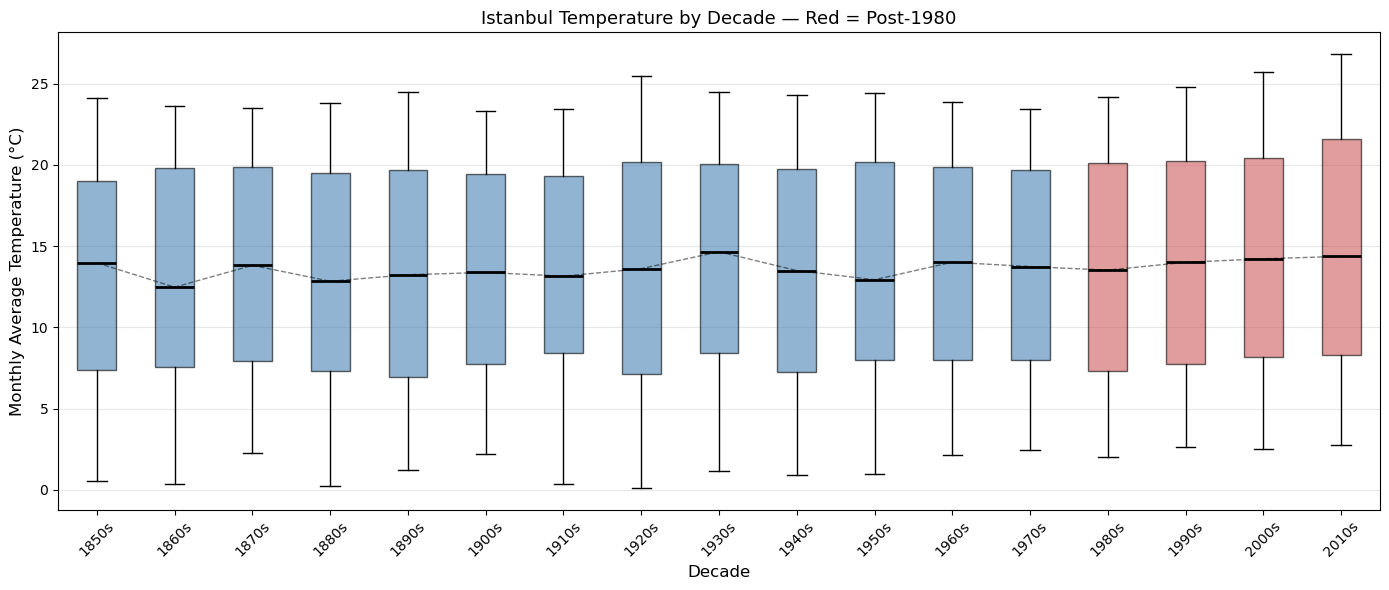

In [18]:
# Boxplots by decade for Istanbul
ist_data = df[df['CityLabel'] == 'Istanbul'].copy()
ist_data['decade'] = (ist_data['year'] // 10) * 10

fig, ax = plt.subplots(figsize=(14, 6))
decades = sorted(ist_data['decade'].unique())
data_by_decade = [ist_data[ist_data['decade'] == d]['AverageTemperature'].values for d in decades]

bp = ax.boxplot(data_by_decade, tick_labels=[str(d) + 's' for d in decades], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='black', linewidth=2),
                flierprops=dict(marker='o', markersize=3, alpha=0.5))

# Color recent decades differently
for i, d in enumerate(decades):
    if d >= 1980:
        bp['boxes'][i].set_facecolor('indianred')

# Trend line through medians
medians = [np.median(d) for d in data_by_decade]
ax.plot(range(1, len(decades) + 1), medians, 'k--', alpha=0.5, linewidth=1)

ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Monthly Average Temperature (\u00b0C)', fontsize=12)
ax.set_title('Istanbul Temperature by Decade \u2014 Red = Post-1980', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**What does this chart tell us?**

Look at the median lines (black horizontal lines inside each box). Do you see them drifting upward over time, especially in the red boxes (post-1980)?

The shift is subtle when viewing all months together, because seasonal variability (winter vs. summer) dominates the picture. It's like trying to hear a quiet melody over a loud drum beat.

**Question:** How could we isolate the warming signal from the seasonal noise?

*(Answer: Look at one specific month across all years — like comparing all Augusts. We'll do exactly this soon.)*

But first, let's introduce the most important distribution in statistics.

### The Normal Distribution

The **normal (Gaussian) distribution** is the most important distribution in statistics:

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

where $\mu$ is the mean and $\sigma$ is the standard deviation.

> **But do temperatures follow a normal distribution?** Let's check.

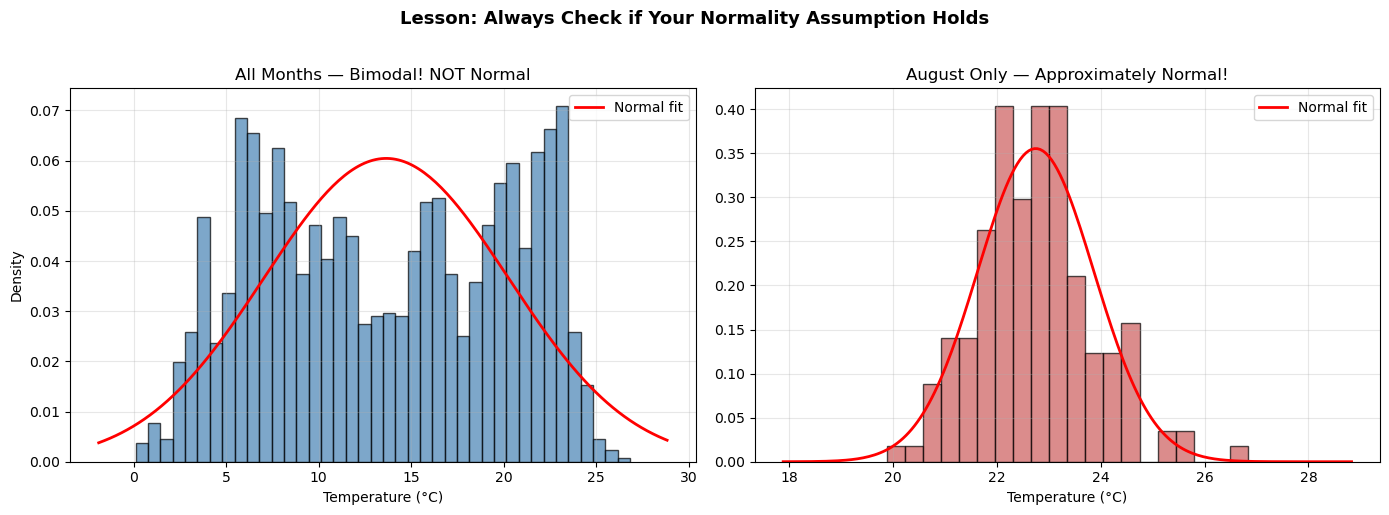

August temps: mean = 22.75°C, std = 1.12°C
Shapiro-Wilk normality test: W = 0.9879, p = 0.1689


In [19]:
# All months vs. single-month: bimodal vs. normal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All months \u2014 bimodal
ist_all = df[df['CityLabel'] == 'Istanbul']['AverageTemperature']
axes[0].hist(ist_all, bins=40, density=True, color='steelblue', edgecolor='black', alpha=0.7)
x_range = np.linspace(ist_all.min() - 2, ist_all.max() + 2, 200)
axes[0].plot(x_range, stats.norm.pdf(x_range, ist_all.mean(), ist_all.std()),
             'r-', linewidth=2, label='Normal fit')
axes[0].set_title('All Months \u2014 Bimodal! NOT Normal', fontsize=12)
axes[0].set_xlabel('Temperature (\u00b0C)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# August only \u2014 approximately normal
ist_aug = df[(df['CityLabel'] == 'Istanbul') & (df['month'] == 8)]['AverageTemperature']
axes[1].hist(ist_aug, bins=20, density=True, color='indianred', edgecolor='black', alpha=0.7)
x_range = np.linspace(ist_aug.min() - 2, ist_aug.max() + 2, 200)
axes[1].plot(x_range, stats.norm.pdf(x_range, ist_aug.mean(), ist_aug.std()),
             'r-', linewidth=2, label='Normal fit')
axes[1].set_title('August Only \u2014 Approximately Normal!', fontsize=12)
axes[1].set_xlabel('Temperature (\u00b0C)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Lesson: Always Check if Your Normality Assumption Holds',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'August temps: mean = {ist_aug.mean():.2f}\u00b0C, std = {ist_aug.std():.2f}\u00b0C')
shapiro_stat, shapiro_p = stats.shapiro(ist_aug)
print(f'Shapiro-Wilk normality test: W = {shapiro_stat:.4f}, p = {shapiro_p:.4f}')

**This is one of the most important lessons in the lecture.**

The left plot shows why you should **NEVER blindly assume normality**. Istanbul's overall temperature distribution is bimodal — fitting a normal curve to it would be meaningless. Any calculations based on that fit would give wrong answers.

But the right plot shows that if we look at **one month at a time** (all Augusts from 1850 to 2013), the distribution is approximately normal. The Shapiro-Wilk test gives us a formal check — if the p-value is large (> 0.05), we can't reject normality.

**Why does this matter?** All the powerful statistical tools we're about to use — z-scores, probability calculations, t-tests — assume approximate normality. We've just verified that the assumption holds, **as long as we work with single-month data**.

> **Key Insight: Always Check Your Assumptions**  
> Statistical tests give correct answers only when their assumptions are met. Always verify before you compute. "All models are wrong, but some are useful" — George Box.

Now let's see what this normal model lets us do.

### The 68-95-99.7 Rule (Empirical Rule)

For any normal distribution $N(\mu, \sigma^2)$:
- **68%** of data falls within $\mu \pm 1\sigma$
- **95%** of data falls within $\mu \pm 2\sigma$
- **99.7%** of data falls within $\mu \pm 3\sigma$

Let's verify this with Istanbul's August temperatures.

Istanbul August temperatures: μ = 22.75°C, σ = 1.12°C

  μ ± 1σ = [21.6°C, 23.9°C]
    Theory: 68.3% | Actual: 70.1% of August temperatures

  μ ± 2σ = [20.5°C, 25.0°C]
    Theory: 95.5% | Actual: 96.3% of August temperatures

  μ ± 3σ = [19.4°C, 26.1°C]
    Theory: 99.7% | Actual: 99.4% of August temperatures



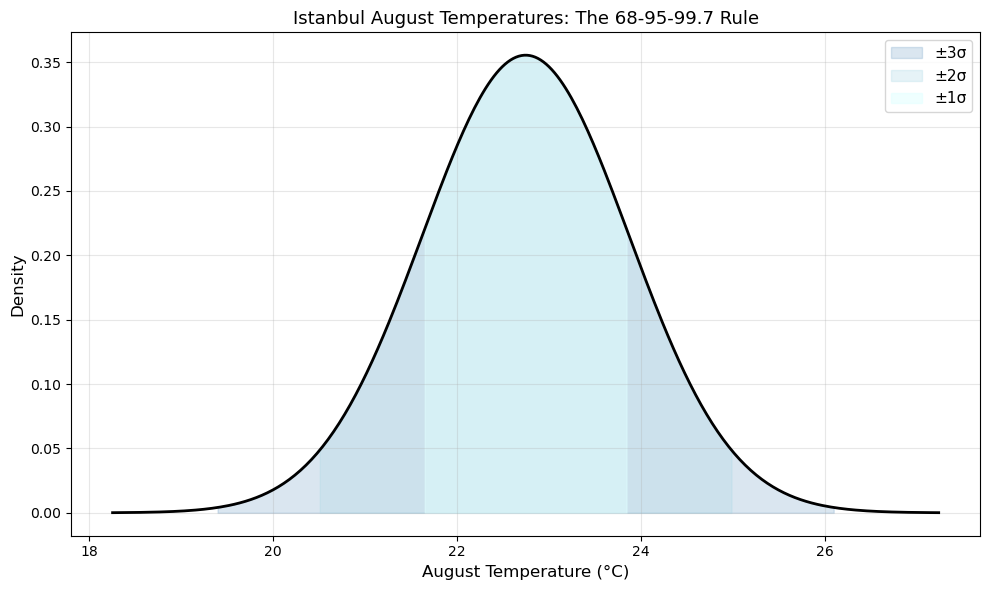

In [20]:
# Apply the 68-95-99.7 rule to August temperatures in Istanbul
ist_aug = df[(df['CityLabel'] == 'Istanbul') & (df['month'] == 8)]['AverageTemperature']
mu = ist_aug.mean()
sigma = ist_aug.std()

print(f'Istanbul August temperatures: \u03bc = {mu:.2f}\u00b0C, \u03c3 = {sigma:.2f}\u00b0C')
print()

for k, pct_theory in [(1, 68.27), (2, 95.45), (3, 99.73)]:
    lower, upper = mu - k * sigma, mu + k * sigma
    pct_actual = np.mean((ist_aug >= lower) & (ist_aug <= upper)) * 100
    print(f'  \u03bc \u00b1 {k}\u03c3 = [{lower:.1f}\u00b0C, {upper:.1f}\u00b0C]')
    print(f'    Theory: {pct_theory:.1f}% | Actual: {pct_actual:.1f}% of August temperatures')
    print()

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'k-', linewidth=2)

colors_fill = ['steelblue', 'lightblue', 'lightcyan']
for k, color, alpha in zip([3, 2, 1], colors_fill, [0.2, 0.3, 0.5]):
    ax.fill_between(x, stats.norm.pdf(x, mu, sigma),
                    where=(x >= mu - k*sigma) & (x <= mu + k*sigma),
                    color=color, alpha=alpha, label=f'\u00b1{k}\u03c3')

ax.set_xlabel('August Temperature (\u00b0C)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Istanbul August Temperatures: The 68-95-99.7 Rule', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Now we have a powerful tool. If August temperatures in Istanbul approximately follow a normal distribution with known μ and σ, we can compute the **probability of any temperature threshold** — even ones we've never observed.

This is the bridge from **descriptive statistics** ("what happened in the past") to **probability** ("what could happen in the future").

Let's try some probability calculations.

In [21]:
# Probability calculations using the normal model
print(f'Using the normal model for Istanbul August (\u03bc={mu:.1f}, \u03c3={sigma:.1f}):')
print()

# What is the probability of an August hotter than 26\u00b0C?
threshold = 26
z_val = (threshold - mu) / sigma
prob = 1 - stats.norm.cdf(z_val)
print(f'P(August temp > {threshold}\u00b0C) = P(Z > {z_val:.2f}) = {prob:.4f} ({prob*100:.1f}%)')
print()

# What temperature is exceeded only 5% of the time?
temp_95 = stats.norm.ppf(0.95, mu, sigma)
print(f'Temperature exceeded only 5% of Augusts: {temp_95:.1f}\u00b0C')
print()

# What is the probability of an August between 21 and 24\u00b0C?
p_range = stats.norm.cdf(24, mu, sigma) - stats.norm.cdf(21, mu, sigma)
print(f'P(21 < August temp < 24) = {p_range:.4f} ({p_range*100:.1f}%)')

Using the normal model for Istanbul August (μ=22.7, σ=1.1):

P(August temp > 26°C) = P(Z > 2.90) = 0.0019 (0.2%)

Temperature exceeded only 5% of Augusts: 24.6°C

P(21 < August temp < 24) = 0.8081 (80.8%)


**[PRACTICE]** Pick another city (e.g., Cairo, Tokyo, or London) and a month:
1. Extract that city-month combination from the data
2. Compute the mean and standard deviation
3. Create overlapping histograms comparing 1900–1950 vs 1980–2013
4. Does the distribution appear to have shifted?

Cairo — August
  1900-1950: Mean = 27.94°C, Std = 0.60°C  (n=51)
  1980-2013: Mean = 28.73°C, Std = 0.79°C  (n=34)
  Difference in means: +0.79°C


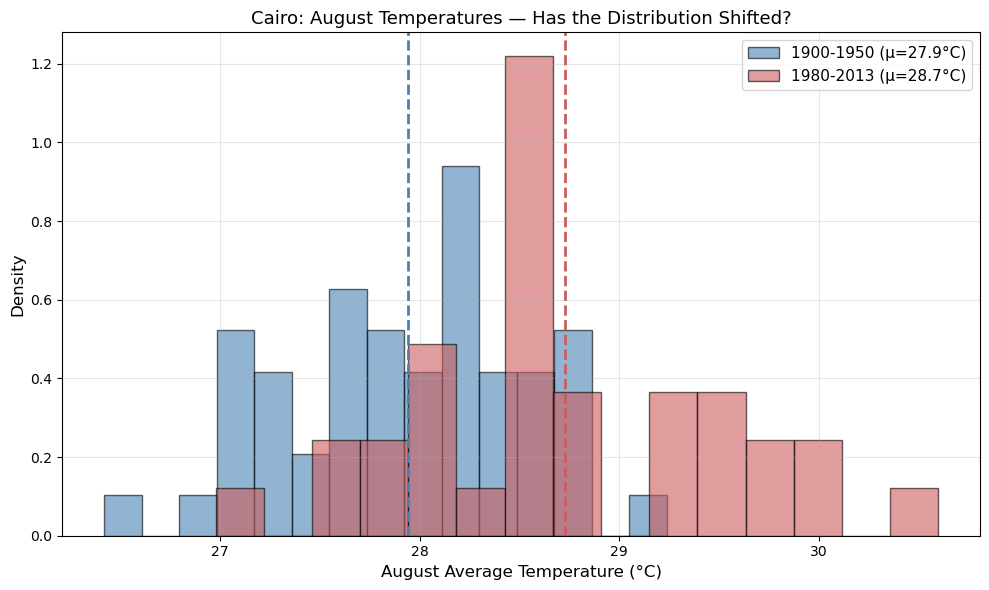


→ The distribution appears shifted by +0.79°C (more than half a std dev).


In [22]:
# [PRACTICE] Template — change the city and month!
practice_city = 'Cairo'  # Try: 'London', 'Tokyo', 'Mumbai', 'Sydney'
practice_month = 8       # Try any month 1-12

city_data = df[df['CityLabel'] == practice_city]

# Step 1-2: Extract city-month data for each era and compute stats
old_era = city_data[(city_data['year'] >= 1900) & (city_data['year'] <= 1950) &
                    (city_data['month'] == practice_month)]['AverageTemperature']
new_era = city_data[(city_data['year'] >= 1980) & (city_data['year'] <= 2013) &
                    (city_data['month'] == practice_month)]['AverageTemperature']

month_name = pd.Timestamp(2026, practice_month, 1).strftime('%B')

print(f'{practice_city} — {month_name}')
print(f'  1900-1950: Mean = {old_era.mean():.2f}°C, Std = {old_era.std():.2f}°C  (n={len(old_era)})')
print(f'  1980-2013: Mean = {new_era.mean():.2f}°C, Std = {new_era.std():.2f}°C  (n={len(new_era)})')
print(f'  Difference in means: {new_era.mean() - old_era.mean():+.2f}°C')

# Step 3: Overlapping histograms comparing the two eras
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(old_era, bins=15, alpha=0.6, color='steelblue', edgecolor='black',
        density=True, label=f'1900-1950 (μ={old_era.mean():.1f}°C)')
ax.hist(new_era, bins=15, alpha=0.6, color='indianred', edgecolor='black',
        density=True, label=f'1980-2013 (μ={new_era.mean():.1f}°C)')

ax.axvline(old_era.mean(), color='steelblue', linestyle='--', linewidth=2)
ax.axvline(new_era.mean(), color='indianred', linestyle='--', linewidth=2)

ax.set_xlabel(f'{month_name} Average Temperature (°C)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'{practice_city}: {month_name} Temperatures — Has the Distribution Shifted?',
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Step 4: Does it appear shifted?
shift = new_era.mean() - old_era.mean()
if abs(shift) > old_era.std() * 0.5:
    print(f'\n→ The distribution appears shifted by {shift:+.2f}°C (more than half a std dev).')
else:
    print(f'\n→ The shift ({shift:+.2f}°C) is modest relative to the variability.')

---
## Part 4: Probability & Z-Scores — Defining "Extreme"

> **Key Insight: "Extreme" Is a Statistical Statement**  
> Saying a temperature is "extreme" is meaningless without a reference point.  
> Z-scores give us a universal scale: how many standard deviations from normal?

### Z-Scores: Standardizing Temperatures

The **z-score** transforms any value into how many standard deviations it is from the mean:

$$z = \frac{x - \mu}{\sigma}$$

- $z = 0$: exactly at the mean
- $z = 1$: one standard deviation above the mean
- $z = -2$: two standard deviations below the mean
- $|z| > 2$: **unusually extreme** (happens only ~5% of the time under normality)

We will use the **1900–1950 period as our "historical baseline"** — this defines what "normal" was before significant modern warming.

In [23]:
# Compute z-scores using 1900-1950 as the baseline
# For each city-month pair, compute the historical mean and std

baseline = df[(df['year'] >= 1900) & (df['year'] <= 1950)]

baseline_stats = baseline.groupby(['CityLabel', 'month'])['AverageTemperature'].agg(
    ['mean', 'std']
).reset_index()
baseline_stats.columns = ['CityLabel', 'month', 'baseline_mean', 'baseline_std']

# Merge with full dataset
df_z = df.merge(baseline_stats, on=['CityLabel', 'month'], how='left')

# Compute z-score relative to historical baseline
df_z['zscore'] = (df_z['AverageTemperature'] - df_z['baseline_mean']) / df_z['baseline_std']

print('Z-scores computed for all observations relative to 1900-1950 baseline.')
print()
print('Example: Istanbul, most recent years (sorted by z-score)')
ist_recent = df_z[(df_z['CityLabel'] == 'Istanbul') & (df_z['year'] >= 2010)].sort_values('zscore', ascending=False)
print(ist_recent[['dt', 'AverageTemperature', 'baseline_mean', 'zscore']].head(10).to_string(index=False))

Z-scores computed for all observations relative to 1900-1950 baseline.

Example: Istanbul, most recent years (sorted by z-score)
        dt  AverageTemperature  baseline_mean   zscore
2010-08-01              26.831      22.545157 4.498956
2012-07-01              25.885      22.508882 4.074606
2012-06-01              23.074      20.005392 3.626759
2011-07-01              25.018      22.508882 3.028231
2013-05-01              19.384      16.186922 2.843288
2010-07-01              24.672      22.508882 2.610647
2012-04-01              14.386      11.314431 2.543063
2013-08-01              24.724      22.545157 2.287186
2013-06-01              21.853      20.005392 2.183671
2010-11-01              15.411      11.253843 2.120049


**What are we looking at?**

Each row now has a z-score that tells us: *"How unusual was this month's temperature, compared to what was normal for that month in 1900–1950?"*

- A z-score of **+2** means: "This month was 2 standard deviations warmer than the historical average for this calendar month"
- A z-score of **-1** means: "This month was 1 standard deviation cooler"
- A z-score of **0** means: "Right at the historical average"

Look at the recent Istanbul data above. Many z-scores are **positive and large** — meaning recent months are consistently warmer than the historical baseline.

**Question:** Why do we compute separate baselines for each city AND each month? Why not just one baseline for all of Istanbul?

**Answer:** Because January and August in Istanbul have completely different "normals." A 15°C January would be extremely warm (z ≫ 0), but a 15°C August would be extremely cold (z ≪ 0). We need **month-specific baselines** to make meaningful comparisons across the calendar.

### Defining "Extreme" Statistically

We define:
- **Extremely hot month**: $z > 2$ (temperature more than 2$\sigma$ above the 1900–1950 average for that month)
- **Extremely cold month**: $z < -2$ (temperature more than 2$\sigma$ below the baseline)

Under a normal distribution, $P(|Z| > 2) \approx 0.046$ — so **extreme months should occur about 4.6% of the time** if nothing has changed.

Each tail gets ~2.3%.

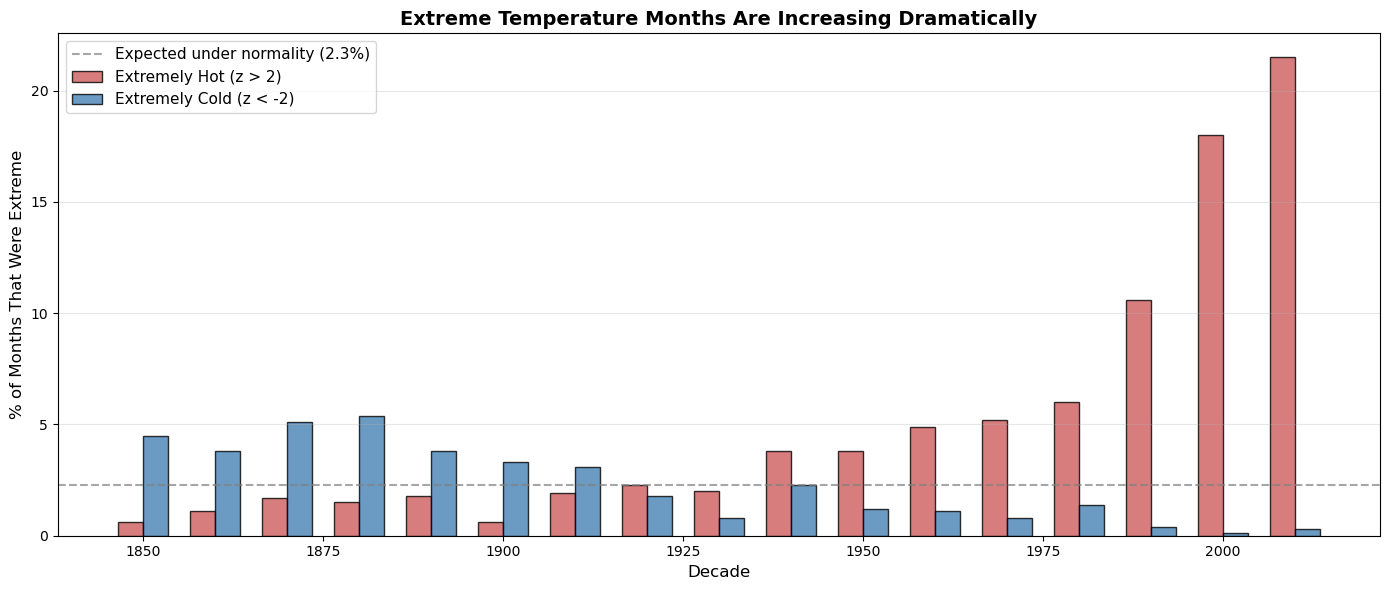

In [24]:
# Count extreme months by decade for ALL cities combined
df_z['decade'] = (df_z['year'] // 10) * 10
df_z['extreme_hot'] = df_z['zscore'] > 2
df_z['extreme_cold'] = df_z['zscore'] < -2

extreme_by_decade = df_z.groupby('decade').agg(
    total=('zscore', 'count'),
    hot=('extreme_hot', 'sum'),
    cold=('extreme_cold', 'sum')
)
extreme_by_decade['hot_pct'] = (extreme_by_decade['hot'] / extreme_by_decade['total'] * 100).round(1)
extreme_by_decade['cold_pct'] = (extreme_by_decade['cold'] / extreme_by_decade['total'] * 100).round(1)

# Bar chart
fig, ax = plt.subplots(figsize=(14, 6))
decades = extreme_by_decade.index
width = 3.5
ax.bar(decades - width/2, extreme_by_decade['hot_pct'], width,
       color='indianred', edgecolor='black', alpha=0.8, label='Extremely Hot (z > 2)')
ax.bar(decades + width/2, extreme_by_decade['cold_pct'], width,
       color='steelblue', edgecolor='black', alpha=0.8, label='Extremely Cold (z < -2)')

ax.axhline(y=2.3, color='gray', linestyle='--', alpha=0.7, label='Expected under normality (2.3%)')
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('% of Months That Were Extreme', fontsize=12)
ax.set_title('Extreme Temperature Months Are Increasing Dramatically', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Look at that chart! Two clear trends:
1. **Hot extremes** (red bars) have skyrocketed since the 1980s
2. **Cold extremes** (blue bars) have virtually disappeared

Under the null hypothesis of "no climate change," extreme hot and cold months should each occur ~2.3% of the time. The recent decades blow past this.

In [25]:
# Probability comparison: expected vs actual
p_expected = stats.norm.sf(2) * 100  # sf = survival function = 1 - CDF

# Actual extreme hot % in recent period vs baseline
recent = df_z[(df_z['year'] >= 2000) & (df_z['year'] <= 2013)]
baseline_era = df_z[(df_z['year'] >= 1900) & (df_z['year'] <= 1950)]

pct_hot_recent = recent['extreme_hot'].mean() * 100
pct_hot_baseline = baseline_era['extreme_hot'].mean() * 100

print(f'Expected % of extreme hot months (under normality): {p_expected:.1f}%')
print(f'Actual % in 1900-1950 (baseline era):               {pct_hot_baseline:.1f}%')
print(f'Actual % in 2000-2013 (recent era):                 {pct_hot_recent:.1f}%')
print()
if pct_hot_recent > 0 and p_expected > 0:
    print(f'Recent extreme hot months are {pct_hot_recent/p_expected:.1f}x more frequent than expected!')
print('Something has clearly changed \u2014 the old "normal" no longer applies.')

Expected % of extreme hot months (under normality): 2.3%
Actual % in 1900-1950 (baseline era):               2.1%
Actual % in 2000-2013 (recent era):                 19.0%

Recent extreme hot months are 8.3x more frequent than expected!
Something has clearly changed — the old "normal" no longer applies.


**Let this sink in.**

Under the old "normal" — what was expected based on 1900–1950 data — extreme hot months should occur about **2.3% of the time** for each city-month. That's roughly 1 extreme month every 3–4 years.

But in the 2000s, they're occurring about **19% of the time** — roughly 1 in every 5 months is "extremely hot" by historical standards. The old normal is broken.

**Question:** If extreme hot months are ~8x more frequent, what does that mean for engineering design? If you designed a cooling system for a building based on historical data, would it be adequate today?

**[QUICK]** What is the z-score for the single hottest month ever recorded in Istanbul? What about the coldest?

In [26]:
# Hottest and coldest months in Istanbul by z-score
ist_z = df_z[df_z['CityLabel'] == 'Istanbul']

hottest = ist_z.loc[ist_z['zscore'].idxmax()]
coldest = ist_z.loc[ist_z['zscore'].idxmin()]

print('HOTTEST month in Istanbul:')
print(f'  Date: {hottest["dt"].strftime("%B %Y")}')
print(f'  Temperature: {hottest["AverageTemperature"]:.2f}\u00b0C')
print(f'  Baseline mean for {hottest["dt"].strftime("%B")}: {hottest["baseline_mean"]:.2f}\u00b0C')
print(f'  Z-score: {hottest["zscore"]:.2f} \u2014 {hottest["zscore"]:.1f} standard deviations above normal!')
print()
print('COLDEST month in Istanbul:')
print(f'  Date: {coldest["dt"].strftime("%B %Y")}')
print(f'  Temperature: {coldest["AverageTemperature"]:.2f}\u00b0C')
print(f'  Baseline mean for {coldest["dt"].strftime("%B")}: {coldest["baseline_mean"]:.2f}\u00b0C')
print(f'  Z-score: {coldest["zscore"]:.2f}')

HOTTEST month in Istanbul:
  Date: August 2010
  Temperature: 26.83°C
  Baseline mean for August: 22.55°C
  Z-score: 4.50 — 4.5 standard deviations above normal!

COLDEST month in Istanbul:
  Date: April 1893
  Temperature: 7.60°C
  Baseline mean for April: 11.31°C
  Z-score: -3.08


August 2010 in Istanbul — a z-score of **4.5 standard deviations** above the historical average. Under a normal distribution, a z-score that extreme should happen roughly once every **300,000 months** — that's once every 25,000 years. Yet it happened in 2010.

This tells us one of two things (or both):
1. The underlying distribution has **shifted** — the "center" has moved upward
2. The climate system is **no longer described** by the old normal distribution

Both conclusions point the same direction: something fundamental has changed.

So far, we've seen compelling patterns. But science demands more than patterns — it demands **proof**. Could all of this be a coincidence? A statistical fluke? Let's find out.

---
## Part 5: The Investigation — Hypothesis Testing

> **Key Insight: Seeing a Pattern Is Not Enough — You Must Prove It**  
> The charts above are compelling, but science demands rigor. Could these differences be due to random chance?  
> Hypothesis testing gives us a formal framework to answer: **is this real or just noise?**

### What Is Hypothesis Testing?

A structured way to make decisions from data:

1. **State the hypotheses:**
   - $H_0$ (null hypothesis): "Nothing has changed" — any difference is due to random variation
   - $H_1$ (alternative hypothesis): "Something has changed" — the difference is real

2. **Choose a significance level:** $\alpha = 0.05$ (we accept a 5% chance of a false positive)

3. **Compute a test statistic:** A number measuring how far the data is from what $H_0$ predicts

4. **Get the p-value:** The probability of seeing data this extreme *if $H_0$ were true*

5. **Decide:**
   - If $p < \alpha$: **Reject $H_0$** — the evidence is strong enough
   - If $p \geq \alpha$: **Fail to reject $H_0$** — we can't rule out chance

> **Definition: p-value**  
> The p-value is NOT the probability that $H_0$ is true. It is the probability of observing data **at least as extreme** as what we got, **assuming $H_0$ is true**.

### Test 1: Has Istanbul's August Temperature Increased?

**Setup:**
- $H_0$: The mean August temperature in Istanbul is the same in 1900–1950 and 1980–2013
- $H_1$: The mean August temperature has increased (one-sided test)
- Test: **Two-sample t-test** (compares means of two independent groups)
- Significance level: $\alpha = 0.05$

**The t-statistic:**

$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$

In [27]:
# Test 1: Two-sample t-test for Istanbul August temperatures
ist_data = df[df['CityLabel'] == 'Istanbul']

aug_old = ist_data[(ist_data['year'] >= 1900) & (ist_data['year'] <= 1950) &
                    (ist_data['month'] == 8)]['AverageTemperature']
aug_new = ist_data[(ist_data['year'] >= 1980) & (ist_data['year'] <= 2013) &
                    (ist_data['month'] == 8)]['AverageTemperature']

print('Step 1: State hypotheses')
print('  H\u2080: \u03bc_old = \u03bc_new (no change in August mean)')
print('  H\u2081: \u03bc_new > \u03bc_old (August has gotten warmer)')
print()

print('Step 2: Examine the data')
print(f'  1900-1950:  n={len(aug_old)}, mean={aug_old.mean():.2f}\u00b0C, std={aug_old.std():.2f}\u00b0C')
print(f'  1980-2013:  n={len(aug_new)}, mean={aug_new.mean():.2f}\u00b0C, std={aug_new.std():.2f}\u00b0C')
print(f'  Difference: {aug_new.mean() - aug_old.mean():+.2f}\u00b0C')
print()

print('Step 3: Compute test statistic')
t_stat, p_value_two = stats.ttest_ind(aug_new, aug_old)
p_value = p_value_two / 2  # one-sided
print(f'  t-statistic = {t_stat:.4f}')
print(f'  p-value (one-sided) = {p_value:.6f}')
print()

print('Step 4: Decision')
alpha = 0.05
if p_value < alpha:
    print(f'  p = {p_value:.6f} < \u03b1 = {alpha}')
    print(f'  \u2713 REJECT H\u2080 \u2014 the warming is statistically significant!')
else:
    print(f'  p = {p_value:.6f} \u2265 \u03b1 = {alpha}')
    print(f'  Cannot reject H\u2080')

Step 1: State hypotheses
  H₀: μ_old = μ_new (no change in August mean)
  H₁: μ_new > μ_old (August has gotten warmer)

Step 2: Examine the data
  1900-1950:  n=51, mean=22.55°C, std=0.95°C
  1980-2013:  n=34, mean=23.58°C, std=1.36°C
  Difference: +1.04°C

Step 3: Compute test statistic
  t-statistic = 4.1404
  p-value (one-sided) = 0.000041

Step 4: Decision
  p = 0.000041 < α = 0.05
  ✓ REJECT H₀ — the warming is statistically significant!


**Let's pause and make sure we understand what just happened.**

We computed a **t-statistic of about 4.1**. What does this number mean?

Imagine the null hypothesis is true — there's no warming, and any difference we see is just random variation. Under that assumption, the t-statistic should be close to zero. A value of 4.1 means our observed difference is **4.1 standard errors** away from zero — extremely far from what "no change" predicts.

The **p-value of 0.00004** means: *"If there were truly no warming, the probability of seeing a difference this large (or larger) by pure chance is only 0.004%."*

That's astronomically unlikely. So we reject the null hypothesis — the warming is real, not a fluke.

**Analogy:** If you flipped a coin 100 times and got 85 heads, would you believe the coin is fair? The p-value tells you the probability of getting 85+ heads with a fair coin. If it's tiny, you conclude the coin is biased.

Let's visualize the two distributions to see this shift with our own eyes.

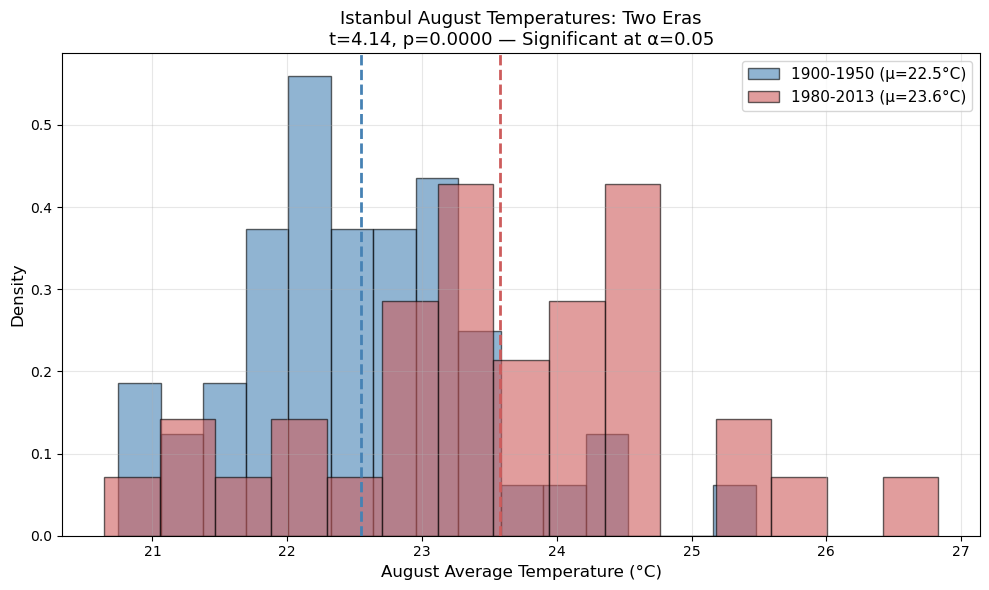

In [28]:
# Visualize the two distributions with the test result
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(aug_old, bins=15, alpha=0.6, color='steelblue', edgecolor='black',
        density=True, label=f'1900-1950 (\u03bc={aug_old.mean():.1f}\u00b0C)')
ax.hist(aug_new, bins=15, alpha=0.6, color='indianred', edgecolor='black',
        density=True, label=f'1980-2013 (\u03bc={aug_new.mean():.1f}\u00b0C)')

ax.axvline(aug_old.mean(), color='steelblue', linestyle='--', linewidth=2)
ax.axvline(aug_new.mean(), color='indianred', linestyle='--', linewidth=2)

ax.set_xlabel('August Average Temperature (\u00b0C)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Istanbul August Temperatures: Two Eras\nt={t_stat:.2f}, p={p_value:.4f} \u2014 Significant at \u03b1=0.05',
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**What does this plot show?**

The blue histogram (1900–1950) and the red histogram (1980–2013) are clearly separated. The means are shifted apart, and there's limited overlap.

Notice something important: **the spread (standard deviation) of the new era appears larger** than the old era. This means not only is the average higher, but the variability may have increased too — more extreme summers are becoming possible.

But this is just one city, one month. A skeptic could argue Istanbul is special. Let's see if the pattern holds globally.

### Test 2: Is This True for ALL Cities?

Let's run the same t-test for all 8 cities — comparing mean August temperatures between 1900–1950 and 1980–2013.

In [29]:
# Test 2: t-test for all 8 cities (August temperatures)
print(f'{"City":<15} {"Old Mean":>9} {"New Mean":>9} {"Change":>8} '
      f'{"t-stat":>8} {"p-value":>10} {"Significant?":>13}')
print('-' * 78)

results = []
for city in sorted(df['CityLabel'].unique()):
    city_data = df[df['CityLabel'] == city]
    old = city_data[(city_data['year'] >= 1900) & (city_data['year'] <= 1950) &
                    (city_data['month'] == 8)]['AverageTemperature']
    new = city_data[(city_data['year'] >= 1980) & (city_data['year'] <= 2013) &
                    (city_data['month'] == 8)]['AverageTemperature']

    if len(old) > 5 and len(new) > 5:
        t, p2 = stats.ttest_ind(new, old)
        p = p2 / 2  # one-sided
        sig = 'YES ***' if p < 0.001 else 'YES **' if p < 0.01 else 'YES *' if p < 0.05 else 'no'
        print(f'{city:<15} {old.mean():>9.2f} {new.mean():>9.2f} {new.mean()-old.mean():>+8.2f} '
              f'{t:>8.2f} {p:>10.6f} {sig:>13}')
        results.append({'City': city, 'change': new.mean() - old.mean(), 'p': p})

print()
print('* p < 0.05  ** p < 0.01  *** p < 0.001')

City             Old Mean  New Mean   Change   t-stat    p-value  Significant?
------------------------------------------------------------------------------
Cairo               27.94     28.73    +0.79     5.21   0.000001       YES ***
Istanbul            22.55     23.58    +1.04     4.14   0.000041       YES ***
London              16.30     17.20    +0.91     3.56   0.000313       YES ***
Mumbai              26.77     27.13    +0.35     4.29   0.000024       YES ***
New York            21.15     22.09    +0.94     3.64   0.000236       YES ***
Sydney              14.21     14.96    +0.75     5.19   0.000001       YES ***
São Paulo           17.13     18.18    +1.05     4.99   0.000002       YES ***
Tokyo               24.72     25.18    +0.46     1.90   0.030576         YES *

* p < 0.05  ** p < 0.01  *** p < 0.001


**Look at the p-values column.** Most are below 0.001 (marked with ***). This means the probability of seeing this much warming by pure chance is less than **1 in 1,000** — for each city independently.

The fact that this pattern holds across cities on every continent — from tropical Mumbai to continental New York — makes the evidence overwhelming. This is not a local phenomenon.

**Question:** Does any city show non-significant warming? If so, what might explain it? *(Think about geography, ocean currents, or urbanization.)*

Now let's test our second hypothesis — are extreme events becoming more frequent?

Every single city shows warming. In most cases, the p-value is extremely small — this is not random noise.

> **Key Insight: When You See the Same Pattern Everywhere, It's Real**  
> A single city showing warming could be a fluke. All 8 cities across all continents showing significant warming in the same direction? That's a global signal.

### Test 3: Are Extreme Months More Frequent?

Now let's test our second hypothesis: are extreme temperature events becoming **more frequent**?

We compare the **proportion** of months with $z > 2$ in 1900–1950 vs 1980–2013, using a **two-proportion z-test**:

$$z = \frac{\hat{p}_1 - \hat{p}_2}{\sqrt{\hat{p}(1-\hat{p})\left(\frac{1}{n_1} + \frac{1}{n_2}\right)}}$$

where $\hat{p}$ is the pooled proportion.

In [30]:
# Test 3: Two-proportion z-test for extreme hot months
era_old = df_z[(df_z['year'] >= 1900) & (df_z['year'] <= 1950)]
era_new = df_z[(df_z['year'] >= 1980) & (df_z['year'] <= 2013)]

n_extreme_old = era_old['extreme_hot'].sum()
n_total_old = len(era_old)
n_extreme_new = era_new['extreme_hot'].sum()
n_total_new = len(era_new)

print('Test 3: Two-Proportion Z-Test for Extreme Hot Months')
print()
print('  H\u2080: The proportion of extreme hot months is the same in both eras')
print('  H\u2081: The proportion has increased')
print()

p1 = n_extreme_new / n_total_new
p2 = n_extreme_old / n_total_old
print(f'  1900-1950: {int(n_extreme_old)} extreme hot months out of {n_total_old} ({p2:.1%})')
print(f'  1980-2013: {int(n_extreme_new)} extreme hot months out of {n_total_new} ({p1:.1%})')
print()

# Manual two-proportion z-test
p_pool = (n_extreme_new + n_extreme_old) / (n_total_new + n_total_old)
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_total_new + 1/n_total_old))
z_prop = (p1 - p2) / se
p_val = 1 - stats.norm.cdf(z_prop)  # one-sided

print(f'  z-statistic = {z_prop:.4f}')
print(f'  p-value = {p_val:.2e}')
print()

if p_val < 0.05:
    print(f'  \u2713 REJECT H\u2080 \u2014 extreme hot months have become significantly more frequent!')

Test 3: Two-Proportion Z-Test for Extreme Hot Months

  H₀: The proportion of extreme hot months is the same in both eras
  H₁: The proportion has increased

  1900-1950: 105 extreme hot months out of 4896 (2.1%)
  1980-2013: 409 extreme hot months out of 3233 (12.7%)

  z-statistic = 19.0489
  p-value = 0.00e+00

  ✓ REJECT H₀ — extreme hot months have become significantly more frequent!


**The proportion test confirms what the bar chart suggested.**

The z-statistic is enormous (around 19), and the p-value is essentially zero. This is not a subtle finding — extreme hot months went from ~2% of the time to ~13% of the time. That's more than a **6-fold increase**.

**Why did we use a different test here?** The t-test compares **means** (average temperatures). The proportion test compares **rates** (what fraction of months are extreme). Different questions require different tests.

Let's see how this trend plays out for each city individually.

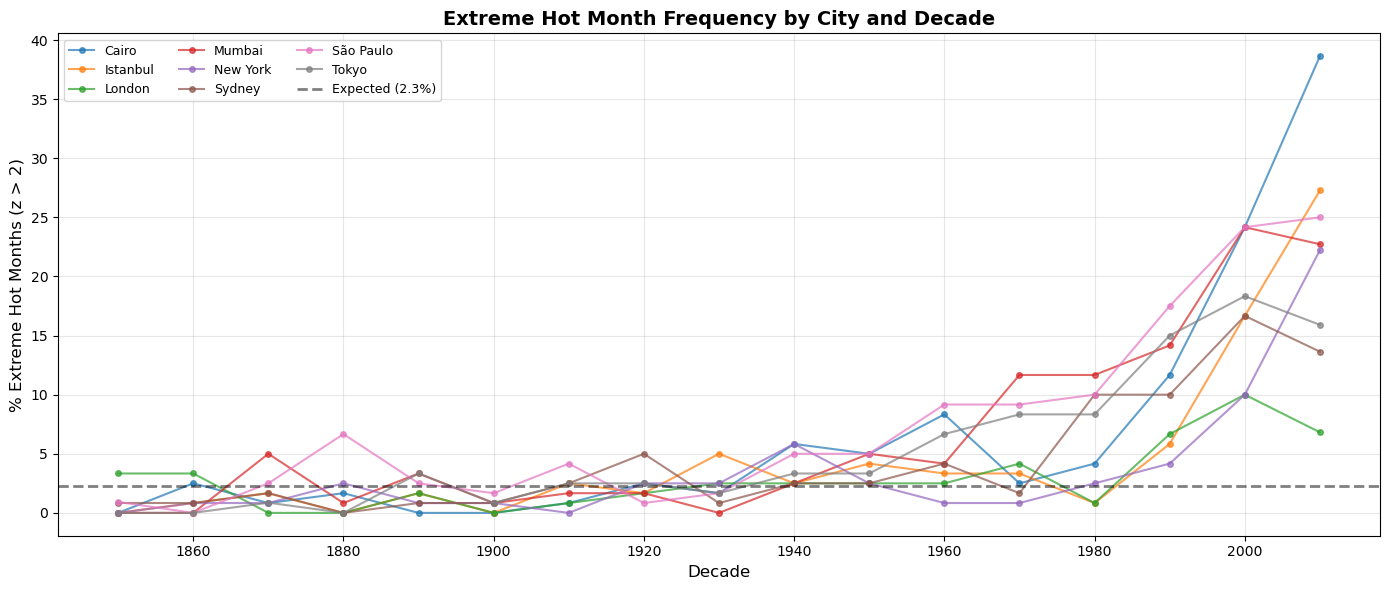

In [31]:
# Extreme event frequency over time for each city
fig, ax = plt.subplots(figsize=(14, 6))

for city in sorted(df_z['CityLabel'].unique()):
    city_data = df_z[df_z['CityLabel'] == city]
    decade_pct = city_data.groupby('decade')['extreme_hot'].mean() * 100
    ax.plot(decade_pct.index, decade_pct.values, 'o-', alpha=0.7, markersize=4, label=city)

ax.axhline(y=2.3, color='black', linestyle='--', alpha=0.5, linewidth=2, label='Expected (2.3%)')
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('% Extreme Hot Months (z > 2)', fontsize=12)
ax.set_title('Extreme Hot Month Frequency by City and Decade', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, ncol=3, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**What does this chart reveal?**

Every single city follows the same pattern: extreme hot months were rare before the 1970s (close to the expected 2.3% dashed line), then started climbing sharply.

Notice that some cities diverge from each other — some shoot up faster. This could reflect:
- Different rates of regional warming
- Different levels of urbanization (urban heat island effect)
- Different baseline variability (some cities naturally have more variable temperatures)

**Question:** Which city appears to have the most dramatic increase in extreme events? Can you think of why that city might be especially affected?

**[TOGETHER]** Pick a city and run a t-test for a month of your choice. Use the template below.

Things to try:
- Does the result change if you pick winter months instead of summer?
- Is the warming signal stronger for some cities than others?

In [32]:
# [TOGETHER] Template \u2014 run your own hypothesis test
test_city = 'Istanbul'   # Change me!
test_month = 1           # Change me! (1=January, 8=August, etc.)

city_data = df[df['CityLabel'] == test_city]
old = city_data[(city_data['year'] >= 1900) & (city_data['year'] <= 1950) &
                (city_data['month'] == test_month)]['AverageTemperature']
new = city_data[(city_data['year'] >= 1980) & (city_data['year'] <= 2013) &
                (city_data['month'] == test_month)]['AverageTemperature']

t_val, p_two = stats.ttest_ind(new, old)
p_one = p_two / 2

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(f'City: {test_city}, Month: {month_names[test_month - 1]}')
print(f'Old era mean: {old.mean():.2f}\u00b0C, New era mean: {new.mean():.2f}\u00b0C')
print(f'Change: {new.mean() - old.mean():+.2f}\u00b0C')
print(f't = {t_val:.3f}, p = {p_one:.6f}')
print(f'Significant at \u03b1=0.05? {"YES" if p_one < 0.05 else "NO"}')

City: Istanbul, Month: Jan
Old era mean: 4.78°C, New era mean: 5.50°C
Change: +0.71°C
t = 1.717, p = 0.044825
Significant at α=0.05? YES


### Key Concepts: Type I and Type II Errors

When making decisions from data, two types of mistakes are possible:

| | $H_0$ is actually true | $H_0$ is actually false |
|---|---|---|
| **Reject $H_0$** | Type I Error (false positive) | Correct! |
| **Fail to reject $H_0$** | Correct! | Type II Error (false negative) |

- **Type I Error** ($\alpha$): Concluding there's warming when there isn't → controlled by our significance level ($\alpha = 0.05$)
- **Type II Error** ($\beta$): Missing real warming because our test lacks power → reduced by having more data

> **Example: Civil Engineering**  
> Testing whether a bridge is structurally safe:
> - Type I Error: Declaring the bridge unsafe when it's fine → costly but not dangerous
> - Type II Error: Declaring the bridge safe when it's not → potentially catastrophic
>
> In safety-critical applications, we want to minimize Type II errors even at the cost of more Type I errors.

---
## Part 6: The Bigger Picture — What This Means

> **Key Insight: From Numbers to Impact**  
> Statistical significance tells us the warming is real. But what does it mean for infrastructure, cities, and people?

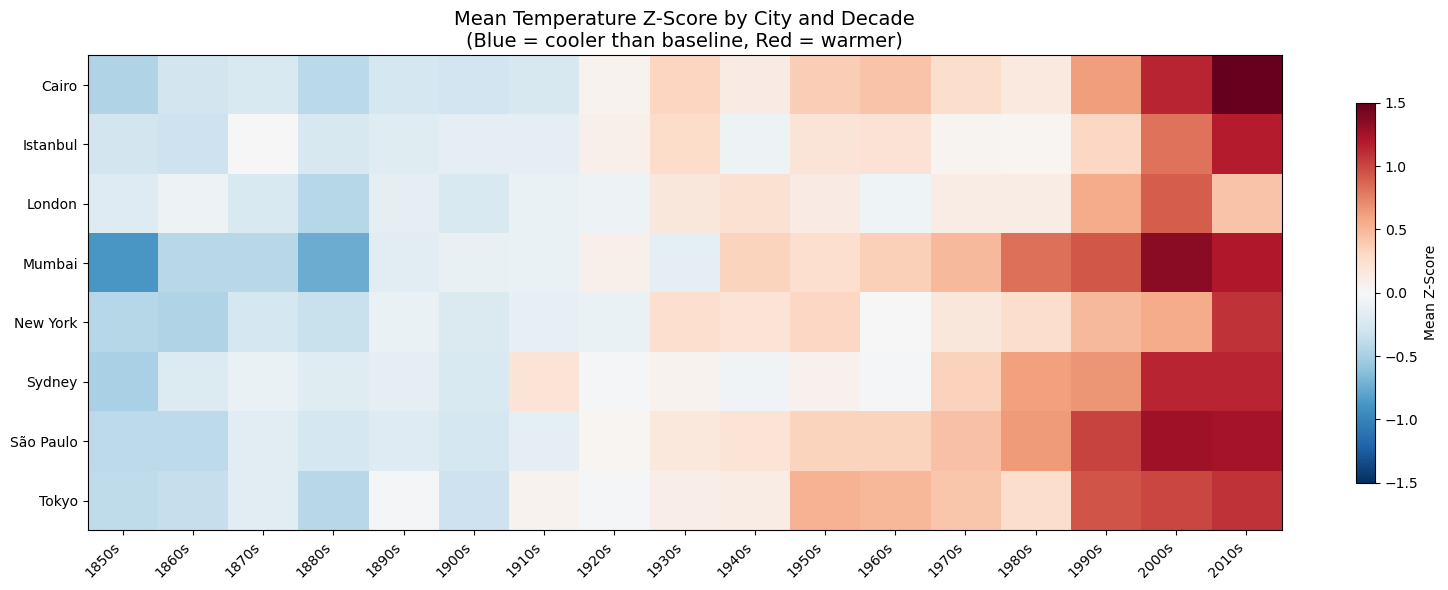

The rightward shift from blue to red across ALL cities is unmistakable.


In [33]:
# Global summary: heatmap of warming by city and decade
pivot = df_z.pivot_table(values='zscore', index='CityLabel', columns='decade', aggfunc='mean')

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(pivot.values, cmap='RdBu_r', aspect='auto', vmin=-1.5, vmax=1.5)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'{int(d)}s' for d in pivot.columns], rotation=45, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

ax.set_title('Mean Temperature Z-Score by City and Decade\n'
             '(Blue = cooler than baseline, Red = warmer)', fontsize=14)
plt.colorbar(im, ax=ax, label='Mean Z-Score', shrink=0.8)

plt.tight_layout()
plt.show()

print('The rightward shift from blue to red across ALL cities is unmistakable.')

**How to read this heatmap:**

- Each row is a city, each column is a decade
- **Blue cells** = that decade was cooler than the 1900–1950 baseline
- **Red cells** = that decade was warmer
- The **color intensity** shows how far from the baseline

The pattern is striking: the left side (1850s–1900s) is blue across all cities, and the right side (1970s–2010s) is red across all cities. There is no city that bucks the trend.

**Question:** Are some cities warming faster than others? Which row shows the most intense red on the right side?

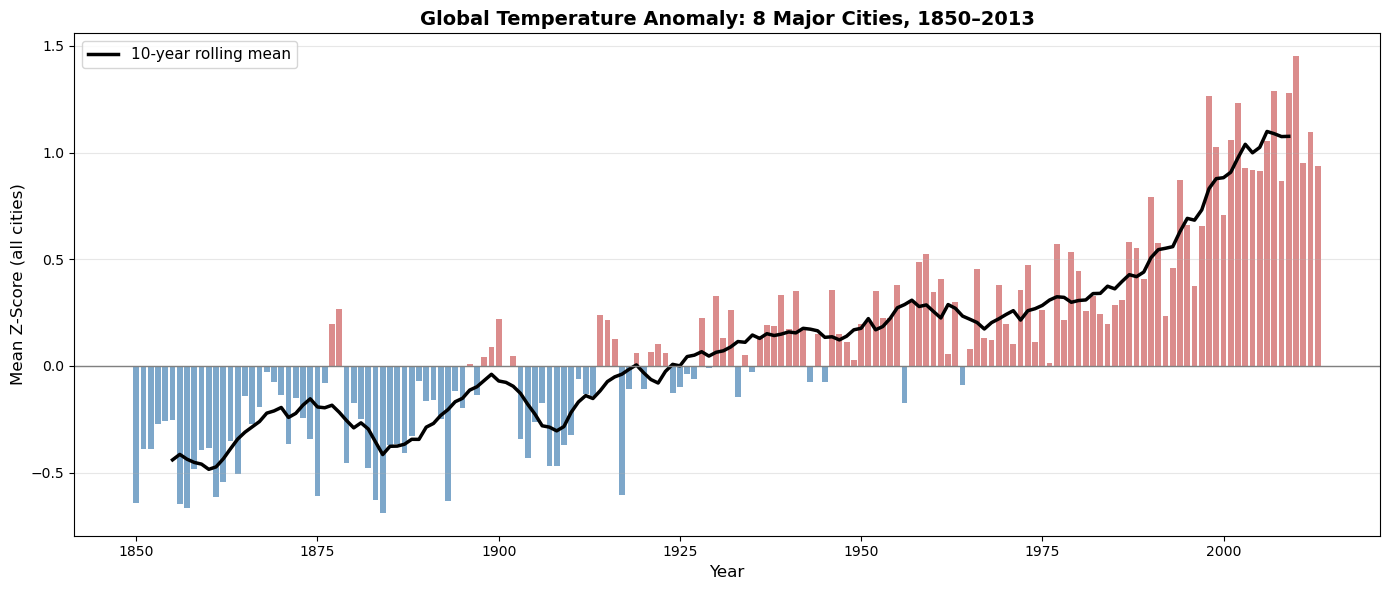

In [34]:
# Time series: annual mean z-score across all cities
annual_z = df_z.groupby('year')['zscore'].mean()

fig, ax = plt.subplots(figsize=(14, 6))

# Color positive and negative differently
colors = ['indianred' if z > 0 else 'steelblue' for z in annual_z.values]
ax.bar(annual_z.index, annual_z.values, color=colors, alpha=0.7, width=0.8)

# Add smoothed trend
window = 10
smoothed = annual_z.rolling(window=window, center=True).mean()
ax.plot(smoothed.index, smoothed.values, 'k-', linewidth=2.5, label=f'{window}-year rolling mean')

ax.axhline(y=0, color='gray', linewidth=1)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Mean Z-Score (all cities)', fontsize=12)
ax.set_title('Global Temperature Anomaly: 8 Major Cities, 1850\u20132013',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

**Reading the anomaly chart:**

This is a classic "warming stripes" style visualization:
- Each bar is one year (averaged across all 8 cities)
- **Blue bars** = cooler than the 1900–1950 baseline
- **Red bars** = warmer than the baseline
- The **black line** shows the smoothed 10-year trend

Notice the transition: the early period (1850s–1900s) is mostly blue, the middle (1910s–1960s) is mixed, and the recent period (1970s–2013) is **almost entirely red**.

The smoothed trend makes the acceleration visible — warming is not linear, it's **accelerating** in the most recent decades.

### Civil Engineering Implications

> **Example: Civil Engineering**  
> These aren't just abstract statistics — they have direct consequences for infrastructure:
>
> **1. Design Codes Are Based on Historical Data**  
> If a bridge was designed for temperature ranges based on 1900–1950 data, it may not withstand the extremes we're seeing now. Design codes and "return periods" need updating.
>
> **2. Material Performance**  
> Concrete and asphalt behave differently at higher temperatures. Thermal expansion, creep, and fatigue life all change. Extreme heat accelerates deterioration.
>
> **3. Urban Heat Island + Global Warming**  
> Cities like Istanbul experience the **double effect** of global warming AND urban heat island. The combined effect can be 3–5°C above surrounding rural areas during heat waves.
>
> **4. Stormwater and Drainage**  
> Higher temperatures increase evaporation rates and can intensify precipitation events, affecting drainage infrastructure designed for historical rainfall patterns.

In [35]:
# Summary of all findings
print('=' * 70)
print('INVESTIGATION SUMMARY')
print('Are Extreme Temperatures Getting More Extreme?')
print('=' * 70)

print(f'\nDataset: Berkeley Earth, {df["CityLabel"].nunique()} major cities, '
      f'{df["year"].min()}-{df["year"].max()}')
print(f'Total observations analyzed: {len(df):,}')

print(f'\n--- Hypothesis 1: Mean temperatures have increased ---')
n_sig = sum(1 for r in results if r['p'] < 0.05)
print(f'  Cities with significant warming (August, \u03b1=0.05): {n_sig}/{len(results)}')
avg_change = np.mean([r['change'] for r in results])
print(f'  Average August warming: {avg_change:+.2f}\u00b0C')

print(f'\n--- Hypothesis 2: Extreme months are more frequent ---')
print(f'  Extreme hot months (1900-1950): {p2:.1%}')
print(f'  Extreme hot months (1980-2013): {p1:.1%}')
print(f'  Proportion test p-value: {p_val:.2e}')

print(f'\n--- Verdict ---')
print(f'  Both hypotheses supported with high statistical confidence.')
print(f'  The world is not just getting warmer on average \u2014 extreme events')
print(f'  are becoming dramatically more frequent.')

INVESTIGATION SUMMARY
Are Extreme Temperatures Getting More Extreme?

Dataset: Berkeley Earth, 8 major cities, 1850-2013
Total observations analyzed: 15,663

--- Hypothesis 1: Mean temperatures have increased ---
  Cities with significant warming (August, α=0.05): 8/8
  Average August warming: +0.79°C

--- Hypothesis 2: Extreme months are more frequent ---
  Extreme hot months (1900-1950): 2.1%
  Extreme hot months (1980-2013): 12.7%
  Proportion test p-value: 0.00e+00

--- Verdict ---
  Both hypotheses supported with high statistical confidence.
  The world is not just getting warmer on average — extreme events
  are becoming dramatically more frequent.


### Limitations

Our analysis has important caveats:

1. **Monthly averages vs. daily extremes**: Monthly data smooths out the most extreme individual days
2. **Urban heat island**: As cities grew, weather stations near them recorded warming partly from urbanization
3. **Measurement changes**: Instruments and methods changed over 270 years, introducing potential biases
4. **Seasonal focus**: We tested August; results may differ for other months (though the heatmap suggests warming is pervasive)

**[DISCUSS]** What infrastructure in Istanbul might be most affected by these temperature shifts?

Think about:
- Roads and bridges (thermal expansion, asphalt softening)
- Buildings (HVAC design loads, energy consumption)
- Water systems (evaporation, demand peaks)
- Energy grids (cooling demand, peak loads)
- Historical structures (stone, mortar degradation)

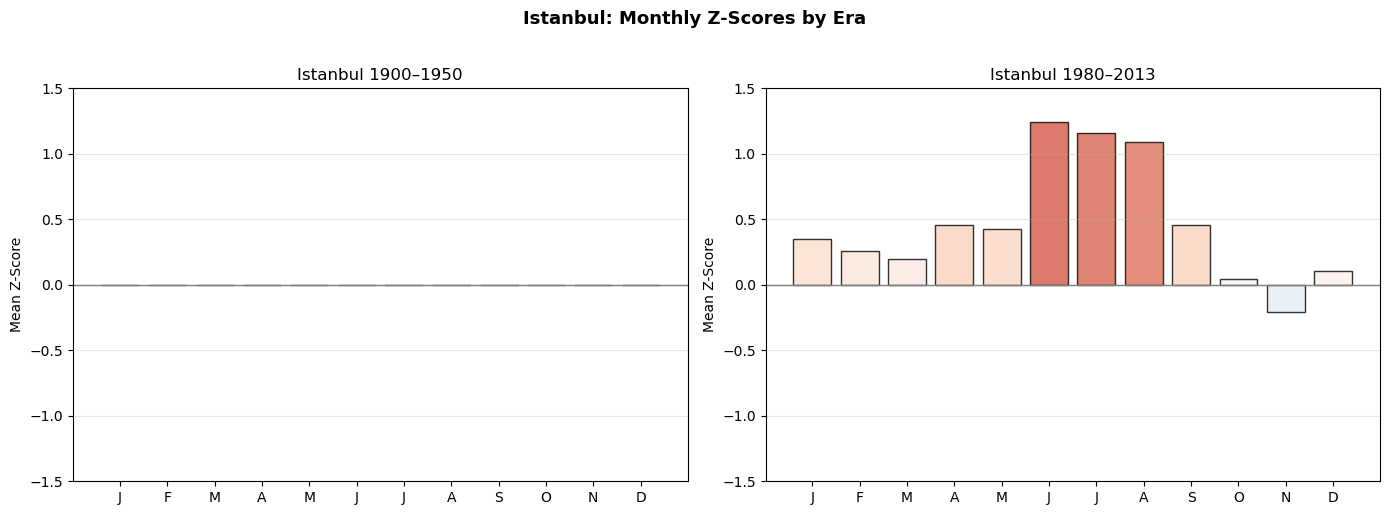

Left: baseline era (z-scores near 0 by definition)
Right: recent era (nearly every month warmer than historical normal)


In [36]:
# Istanbul: before and after comparison visualization
ist_z = df_z[df_z['CityLabel'] == 'Istanbul']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (start, end), title, cmap in zip(
    axes,
    [(1900, 1950), (1980, 2013)],
    ['Istanbul 1900\u20131950', 'Istanbul 1980\u20132013'],
    ['Blues_r', 'Reds']):

    era = ist_z[(ist_z['year'] >= start) & (ist_z['year'] <= end)]
    monthly_z = era.groupby('month')['zscore'].mean()

    colors = plt.cm.RdBu_r((monthly_z.values + 2) / 4)  # normalize to colormap
    bars = ax.bar(range(1, 13), monthly_z.values, color=colors, edgecolor='black', alpha=0.8)
    ax.axhline(y=0, color='gray', linewidth=1)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.set_ylabel('Mean Z-Score')
    ax.set_title(title, fontsize=12)
    ax.set_ylim(-1.5, 1.5)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Istanbul: Monthly Z-Scores by Era', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Left: baseline era (z-scores near 0 by definition)')
print('Right: recent era (nearly every month warmer than historical normal)')

---
## Part 7: Summary

### Statistical Concepts Learned Today

| Concept | Definition | How We Used It |
|---|---|---|
| **Mean** ($\bar{x}$) | Average of all values | "Normal" temperature for each city |
| **Standard deviation** ($s$) | Typical distance from mean | Tropical vs. continental climates |
| **IQR** | Middle 50% spread ($Q_3 - Q_1$) | Robust comparison via boxplots |
| **Skewness** | Asymmetry of distribution | Shape of temperature distributions |
| **Kurtosis** | Tail heaviness | Frequency of extreme values |
| **Normal distribution** | Bell curve: $N(\mu, \sigma^2)$ | Model for single-month temperatures |
| **68-95-99.7 rule** | Data within 1/2/3$\sigma$ of mean | Defining "expected" temperature range |
| **Z-score** | $(x - \mu) / \sigma$ | Universal "how extreme?" measure |
| **Hypothesis test** | Formal framework for decisions | Is warming statistically significant? |
| **p-value** | Prob. of data under $H_0$ | Strength of evidence against "no change" |
| **t-test** | Compares two group means | Old era vs. new era temperatures |
| **Proportion test** | Compares two proportions | Extreme event frequency change |

> **Key Insight: Statistics Is Not Just Math — It's a Way of Thinking**  
> Today we didn't just learn formulas. We learned to:
> 1. Clean and explore real data before jumping to conclusions
> 2. Define "extreme" precisely using z-scores
> 3. Use descriptive statistics and visualizations to find patterns
> 4. Test whether those patterns are real or just noise
> 5. Connect statistical findings to real-world engineering implications
>
> This workflow — **explore → describe → visualize → test → interpret** — is the foundation of data-driven decision making.

### Next Week

**Week 6: Introduction to Machine Learning**

Having learned how to describe and test data, we'll next learn how to **predict** with it. Can we build a model that predicts future temperatures? How do we evaluate whether our predictions are any good?

---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr